# 2 Class Definitions of the Simulated Data and Analysis #

In [64]:
from phase_space_simulation import (
    Widmark1DSimulation,
    Widmark1DAnalysis,
    fit_h_pc_dm_mle_fast,
    plot_phase_space_hist,
)
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


In [65]:
# ==========================================================
# Shared constants (sampling / evolution / fitting moved to Cell 3 loop)
# ==========================================================
import math as _m
h_true = 250.0
t_obs = 400.0  # Myr

sim = Widmark1DSimulation(h_pc_dm=h_true)
ana = Widmark1DAnalysis(sim)

# Initial distribution f0 (what the likelihood assumes) -- now placed at VERTICAL
# EQUILIBRIUM in the Gaussian / harmonic approximation: sigma_z is LOCKED to
# sigma_w by the potential,  sigma_z = sigma_w / nu ,  nu = sqrt(4 pi G rho_tot(0))
# (vertical period ~80 Myr).  Previously z0_sigma = 10 pc, i.e. ~26x too thin --
# a cold midplane sheet FAR out of equilibrium.  This near-equilibrium Gaussian
# still breathes ~12% against the ANHARMONIC potential, and that anharmonic
# phase-mixing (no satellite involved) is what makes the realistic spiral seen
# in the mean-subtraction (df/dt != 0) plot.
w0_sigma = 20.0
_nu = _m.sqrt(4.0 * _m.pi * sim.G * (sim.rho0_thin + sim.rho0_thick + sim.rho0_gas + sim.rho_DM))
z0_sigma = w0_sigma / _nu          # ~259 pc for sigma_w = 20 km/s
def sz_eq(sw):                     # equilibrium sigma_z for ANY sigma_w (sigma_z = sigma_w / nu)
    return sw / _nu
print(f"equilibrium IC: sigma_w = {w0_sigma:.0f} km/s -> sigma_z = {z0_sigma:.1f} pc "
      f"(nu = {_nu:.4f} (km/s)/pc, vertical period {2*_m.pi/_nu/sim.MYR_TO_TUNIT:.0f} Myr)")


equilibrium IC: sigma_w = 20 km/s -> sigma_z = 259.4 pc (nu = 0.0771 (km/s)/pc, vertical period 80 Myr)


In [ ]:
import importlib, phase_space_plot
importlib.reload(phase_space_plot)
from phase_space_plot import plot_phase_space_before_after

# Widmark Fig. A.1 comparison. All 3 panels are STAR-COUNT (number-density) maps
# like the paper -- NOT scatter coloured by phase angle (that paints a fake spiral).
#   panel 1: t=0 equilibrium   panel 2: t=400 raw counts (spiral is faint, as in Gaia)
#   panel 3: mean-subtracted (n-nbar)/nbar  <- the spiral shows up here.
# Gentle Sigma_sat=2.5 keeps the core smooth (~20% spiral); sim default 6 churns it.
#   cleaner 1-armed spiral: use_satellite=False, boost_kms=4
#   tighter multi-wrap snail: raise t_obs (winding is set by TIME, not amplitude)
plot_phase_space_before_after(
    sim, z0_sigma=z0_sigma, w0_sigma=w0_sigma,
    t_obs=t_obs, h_true=h_true, seed=0,
    equilibrium=True, N_resid=300_000,
    use_satellite=True, Sigma_sat=2.5, boost_kms=0.0,
    save_path='plots/phase_space_before_after.png',
)


In [ ]:
# ---- Widmark-style phase-space spiral: EQUILIBRIUM DF + satellite perturbation ----
# Faithful to Widmark et al. (2021), Fig. A.1: a DENSE, stationary equilibrium
# background (all disk components sampled from exp(-Phi/sigma_w^2)) with the
# satellite perturbation phase-mixed into a spiral by the ANHARMONICITY of Phi.
# (A harmonic Phi would only rotate the perturbation rigidly -- no winding.)
# The thin-Gaussian IC used by the inference tests is non-equilibrium and winds
# up the WHOLE population, which is why its centre looked under-occupied.
import importlib, phase_space_plot
importlib.reload(phase_space_plot)
from phase_space_plot import plot_widmark_spiral

_ = plot_widmark_spiral(
    sim, t_obs=t_obs, h_true=h_true,
    N=300_000, Sigma_sat=10.0,   # satellite strength; None -> sim default (6)
    n_steps=8000, seed=0,
    save_path='plots/spiral_widmark.png')


In [ ]:
# ---- df/dt != 0 demonstration: mean-subtracted phase space at t=0 vs t=400 Myr ----
# The STEADY-STATE background f=f(E) is subtracted (phase-average at fixed energy
# E = 1/2 w^2 + Phi(z)). A steady DF depends only on E, so at t=0 (equilibrium) the
# residual is flat (noise). At t=400 Myr a spiral has wound up -> coherent pattern.
# The change between the two panels IS df/dt != 0 (the DF is not in steady state).
import importlib, phase_space_plot
importlib.reload(phase_space_plot)
from phase_space_plot import plot_mean_subtraction_two_times

_ = plot_mean_subtraction_two_times(
    sim, t_obs=t_obs, h_true=h_true,
    N=300_000, Sigma_sat=2.5, boost_kms=0.0, use_satellite=True, seed=0,
    save_path='plots/mean_subtraction_t0_t400.png')


# phase space evolution video #

In [ ]:
import importlib
import orbit_animation
importlib.reload(orbit_animation)          # pick up the new `harmonic` argument
from orbit_animation import animate_orbits
from IPython.display import Image

# ---- POTENTIAL TOGGLE ----
# harmonic = False -> full sech^2 galactic potential (anharmonic, softens at high |z|)
# harmonic = True  -> pure harmonic potential Phi(z) = 0.5 * omega^2 * z^2,
#                     with omega^2 = Phi''(0) matched to the true midplane curvature.
# The two agree near z=0 and diverge at large |z|; comparing the two gifs shows
# how anharmonicity (the part that actually constrains h_dm) reshapes the orbits.
harmonic = False

# Toggle the time-dependent satellite kick (ignored when harmonic=True)
use_satellite = False

save_path = 'plots/phase_space_orbits_harmonic.gif' if harmonic else 'plots/phase_space_orbits.gif'
anim = animate_orbits(sim, save_path=save_path,
                      use_satellite=use_satellite, harmonic=harmonic)

# Display the saved gif inline -- what you see is the actual saved file
Image(filename=save_path)


# Test 1 — Frozen biased Gaussian DF, only $h_{\rm dm}$ free: the fit breaks

*(Replaces the old cold-regime mismatch sweep.)* Companion to **Test 3**, in the **anharmonic / equilibrium regime** ($\sigma_z\approx259$ pc, $\sigma_w=20$ km/s, no satellite). Where Test 3 lets the full Gaussian DF ($\mu,\sigma$ in $z,w$) float and *recovers* the truth, here we do the opposite: we **freeze** the Gaussian at a deliberately **biased** value — $\sigma_w$ mismatched **down by a factor of 40** ($\sigma_w^{\rm fit}=0.5$ km/s vs. true 20) — and let **only $h_{\rm dm}$** move (no NN).

**Point.** With a wrong, frozen $f_0$, the one remaining knob $h_{\rm dm}$ cannot absorb the mismatch: it is dragged to a badly wrong value while the assumed PDF stays visibly wrong. Same six diagnostics as Test 3 (h-convergence, means, sigmas, [NN disabled], recovered DF) — now showing **failure**, not recovery.

**Expected:** $h_{\rm dm}$ collapses toward the lower bound (huge negative bias), and the recovered-DF panel shows the frozen thin-$\sigma_w$ ellipse missing the back-integrated data entirely. ⏱ ~2–3 min.

In [ ]:
# ============================================================================
# TEST 1 (NEW) -- Frozen BIASED Gaussian DF, only h_dm free: the fit FAILS.
#   Anharmonic / equilibrium regime (sigma_z ~ 259 pc, sigma_w = 20 km/s).
#   Companion/opposite of Test 3: Test 3 lets the full Gaussian DF float and
#   RECOVERS the truth; here we FREEZE the DF at a biased sigma_w (mismatched
#   DOWN by a factor of 40 -> sigma_w_fit = 0.5 km/s) and let ONLY h_dm move
#   (no NN).  The one remaining knob cannot absorb a wrong f0 -> wrong PDF AND
#   wrong h.  Clean data: static h_true, NO satellite.
# ============================================================================
import importlib, os, numpy as np, math as _math, time as _t
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Ellipse
from scipy.stats import skew, kurtosis
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_freegaussian_nn_mle, torch_back_integrate

# ---- KNOBS ----
N_1        = 2000
BIAS_RATIO = 40.0                      # sigma_w_true / sigma_w_fit  (significant bias)
SW_FIT_1   = w0_sigma / BIAS_RATIO     # frozen, BIASED sigma_w  (= 0.5 km/s)
SZ_FIT_1   = z0_sigma                  # frozen at TRUTH (~259 pc)
H_INIT_1   = 250.0                     # start AT truth -> watch the bias drag h away

# ---- clean dataset: static h_true, no satellite (equilibrium/anharmonic IC) ----
z0_d1, w0_d1 = sim.sample_near_midplane(N=N_1, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=0)
Zs1, Ws1, _  = sim.evolve_record(z0_d1, w0_d1, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
                                 seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs_1, w_obs_1 = Zs1[-1].astype(np.float64), Ws1[-1].astype(np.float64)
print(f"Data: N={N_1}, static h_true={h_true}, no satellite. "
      f"True DF sigma=({z0_sigma:.0f} pc, {w0_sigma:.0f} km/s).")
print(f"Fit: DF FROZEN [mu=0, sigma_z={SZ_FIT_1:.0f}, sigma_w={SW_FIT_1:.2f} "
      f"(BIASED x{BIAS_RATIO:.0f})];  only h_dm free;  no NN.\n")

# ---- fit: ONLY h_dm free; Gaussian frozen (biased sigma_w); NN off ----
t0 = _t.time()
res1 = fit_h_freegaussian_nn_mle(
    sim, z_obs_1, w_obs_1, t_obs,
    z0_sigma=z0_sigma, w0_sigma=w0_sigma,
    mu_z_init=0.0, mu_w_init=0.0,
    z0_sigma_fit_init=SZ_FIT_1, w0_sigma_fit_init=SW_FIT_1,
    h_init=H_INIT_1, use_nn_correction=False, use_satellite=False,
    fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
    n_epochs=200, n_sub=500, n_steps=2000,
    h_bounds=(20.0, 3000.0), seed=42, verbose=True)
h_fit = res1['h_pc_dm_fitted']
print(f"\nFit done in {(_t.time()-t0)/60:.1f} min")

# ---- back-integrate observed stars to t=0 at the fitted (wrong) h ----
with torch.no_grad():
    _z0bi, _w0bi = torch_back_integrate(
        torch.tensor(z_obs_1, dtype=torch.float64), torch.tensor(w_obs_1, dtype=torch.float64),
        t_obs, torch.tensor(h_fit, dtype=torch.float64),
        sim, n_steps=3000, use_satellite=False, use_nn_correction=False)
z0bi, w0bi = _z0bi.numpy(), _w0bi.numpy()

# ---- recovery table ----
truth = dict(h_dm=h_true, mu_z=0.0, mu_w=0.0, sigma_z=z0_sigma, sigma_w=w0_sigma)
fitv  = dict(h_dm=h_fit, mu_z=res1['mu_z_fitted'], mu_w=res1['mu_w_fitted'],
             sigma_z=res1['sigma_z_fitted'], sigma_w=res1['sigma_w_fitted'])
print(f"{'param':>10s}  {'truth':>10s}  {'fitted':>10s}  {'error':>12s}   (DF frozen; only h free)")
print('-' * 62)
for k in ['h_dm', 'mu_z', 'mu_w', 'sigma_z', 'sigma_w']:
    tr, ft = truth[k], fitv[k]
    if abs(tr) > 1e-9:
        print(f"{k:>10s}  {tr:10.3f}  {ft:10.3f}  {(ft-tr)/tr*100:+9.2f} %")
    else:
        print(f"{k:>10s}  {tr:10.3f}  {ft:10.3f}  {ft-tr:+8.3f} (abs)")
print(f"\n=> h_dm dragged to {h_fit:.1f} pc ({(h_fit-h_true)/h_true*100:+.1f}% vs truth) by the frozen "
      f"biased PDF.  Back-integrated t=0 marginals: "
      f"z(skew={skew(z0bi):+.2f}, exkurt={kurtosis(z0bi):+.2f}), "
      f"w(skew={skew(w0bi):+.2f}, exkurt={kurtosis(w0bi):+.2f}).")

def _gauss(x, mu, s):
    return np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))

# ---- plots: 2x2 (top-left = h convergence; other 3 = t=0 marginals + DF) ----
fig, axs = plt.subplots(2, 2, figsize=(13, 9), dpi=130)

# (0,0) h convergence
axs[0, 0].plot(res1['h_history'], 'C0')
axs[0, 0].axhline(h_true, color='k', ls='--', label=f'true {h_true:.0f}')
axs[0, 0].set_title('$h_{\\rm dm}$ [pc]  (the ONLY free parameter)'); axs[0, 0].set_xlabel('epoch')
axs[0, 0].legend(); axs[0, 0].grid(alpha=.3)

# (0,1) t=0 distribution in w: back-int obs vs matched Gaussian vs assumed (biased) f0
ax = axs[0, 1]
cnt, _ = np.histogram(w0bi, bins=60, density=True)
ax.hist(w0bi, bins=60, density=True, color='C0', alpha=.55, label='back-int obs @ $t=0$')
wg = np.linspace(w0bi.min(), w0bi.max(), 400)
ax.plot(wg, _gauss(wg, w0bi.mean(), w0bi.std()), 'k--', lw=2, label='matched Gaussian')
ax.plot(wg, _gauss(wg, res1['mu_w_fitted'], res1['sigma_w_fitted']), 'C3', lw=2,
        label=f"assumed $f_0$ ($\\sigma_w$={res1['sigma_w_fitted']:.1f}, off-scale)")
ax.set_ylim(0, 1.45 * cnt.max())
ax.set_title(f'$t=0$ distribution in $w$  (skew={skew(w0bi):+.2f}, exkurt={kurtosis(w0bi):+.2f})')
ax.set_xlabel('w [km/s]'); ax.set_ylabel('density'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# (1,0) t=0 distribution in z: back-int obs vs matched Gaussian vs assumed f0
ax = axs[1, 0]
cnt, _ = np.histogram(z0bi, bins=60, density=True)
ax.hist(z0bi, bins=60, density=True, color='C0', alpha=.55, label='back-int obs @ $t=0$')
zg = np.linspace(z0bi.min(), z0bi.max(), 400)
ax.plot(zg, _gauss(zg, z0bi.mean(), z0bi.std()), 'k--', lw=2, label='matched Gaussian')
ax.plot(zg, _gauss(zg, res1['mu_z_fitted'], res1['sigma_z_fitted']), 'C3', lw=2,
        label=f"assumed $f_0$ ($\\sigma_z$={res1['sigma_z_fitted']:.0f})")
ax.set_ylim(0, 1.45 * cnt.max())
ax.set_title(f'$t=0$ distribution in $z$  (skew={skew(z0bi):+.2f}, exkurt={kurtosis(z0bi):+.2f})')
ax.set_xlabel('z [pc]'); ax.set_ylabel('density'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# (1,1) recovered initial DF (2-D): back-integrated obs vs frozen (biased) fitted ellipse
ax = axs[1, 1]
ax.scatter(z0bi, w0bi, s=4, alpha=.3, color='C3', label='back-integrated obs')
ax.add_patch(Ellipse((0, 0), 4*z0_sigma, 4*w0_sigma,
                     fill=False, edgecolor='k', lw=2, ls='--', label='true 2$\\sigma$'))
ax.add_patch(Ellipse((res1['mu_z_fitted'], res1['mu_w_fitted']),
                     4*res1['sigma_z_fitted'], 4*res1['sigma_w_fitted'],
                     fill=False, edgecolor='C3', lw=2, label='fitted 2$\\sigma$ (frozen, biased)'))
ax.set_xlabel('z [pc]'); ax.set_ylabel('w [km/s]')
ax.set_title('Recovered initial DF (t=0): frozen thin-$\\sigma_w$ PDF misses the data')
ax.legend(fontsize=8); ax.grid(alpha=.3)

fig.suptitle(f'Test 1: FROZEN biased Gaussian ($\\sigma_w$ x{BIAS_RATIO:.0f}), only $h_{{\\rm dm}}$ free '
             f'-> the fit FAILS  ($h_{{\\rm dm}}$={h_fit:.0f} vs truth {h_true:.0f})', y=1.01, fontsize=13)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/test1_frozen_biased_gaussian.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/test1_frozen_biased_gaussian.png')


In [ ]:
# Phase-space visualisation
# Requires Cell 7 to have been run (h_z, h_w, z_obs, w_obs, z0_d, w0_d defined)
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Ellipse
from fitter import torch_back_integrate

def back_integrate_coords(h_fit, n_steps=3000):
    z0, w0 = torch_back_integrate(
        torch.tensor(z_obs, dtype=torch.float64),
        torch.tensor(w_obs, dtype=torch.float64),
        t_obs,
        torch.tensor(float(h_fit), dtype=torch.float64),
        sim,
        n_steps=n_steps, use_satellite=True,
    )
    return z0.detach().numpy(), w0.detach().numpy()

def gauss_ellipse(ax, sigma_z, sigma_w, nsigma=2, **kw):
    ax.add_patch(Ellipse((0, 0),
                         width=2*nsigma*sigma_z, height=2*nsigma*sigma_w,
                         facecolor='none', **kw))

# ── Plot 1: reference ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=130)

ax = axes[0]
ax.scatter(z0_d, w0_d, s=5, alpha=0.4, color='C0', label='Stars at t = 0')
gauss_ellipse(ax, z0_sigma, w0_sigma, nsigma=1, edgecolor='C0', lw=2,  label='1σ true')
gauss_ellipse(ax, z0_sigma, w0_sigma, nsigma=2, edgecolor='C0', lw=1,  label='2σ true', linestyle='--')
ax.set_xlabel('z  [pc]'); ax.set_ylabel('w  [km/s]')
ax.set_title('True initial conditions  (t = 0)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(z_obs, w_obs, s=5, alpha=0.4, color='C3', label='Stars at t = {:.0f} Myr'.format(t_obs))
ax.set_xlabel('z  [pc]'); ax.set_ylabel('w  [km/s]')
ax.set_title('Observed data  (t = {:.0f} Myr)'.format(t_obs))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Reference phase space', fontsize=12)
plt.tight_layout()
plt.savefig('plots/mismatch_reference_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: back-integrated t=0 — only σ_z and σ_w sweeps (no "both") ──────
sweep_labels = [r'$\sigma_z$ mismatched only  ($\sigma_w$ at truth)',
                r'$\sigma_w$ mismatched only  ($\sigma_z$ at truth)']
h_fits_all   = [h_z, h_w]
z_sf_all     = [z0_sf_list,             [z0_sigma]*len(ratios)]
w_sf_all     = [[w0_sigma]*len(ratios), w0_sf_list]

# shared legend handles
leg_handles = [
    mlines.Line2D([], [], color='grey', marker='o', ms=5, ls='none', alpha=0.5,
                  label='True data  (t = 0)'),
    mlines.Line2D([], [], color='C1',   marker='o', ms=5, ls='none', alpha=0.7,
                  label='Back-integrated to t = 0  (fitted h_dm)'),
    mlines.Line2D([], [], color='C1',   lw=2.0, ls='-',
                  label='2σ ellipse assumed by fit'),
    mlines.Line2D([], [], color='grey', lw=1.5, ls='--',
                  label='2σ true distribution'),
]

n_rows = len(ratios)
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 4 * n_rows), dpi=120)
if n_rows == 1:
    axes = np.array([axes])
fig.suptitle('Back-integrated t = 0 phase space per fit', fontsize=13, y=1.01)

for col, (slabel, h_fits, z_sfs, w_sfs) in enumerate(
        zip(sweep_labels, h_fits_all, z_sf_all, w_sf_all)):
    axes[0, col].annotate(slabel, xy=(0.5, 1.18), xycoords='axes fraction',
                          ha='center', va='bottom', fontsize=10, fontweight='bold')
    for row, (rat, h_fit, z_sf, w_sf) in enumerate(
            zip(ratios, h_fits, z_sfs, w_sfs)):
        ax = axes[row, col]

        # true t=0 data (grey)
        ax.scatter(z0_d, w0_d, s=3, alpha=0.25, color='grey', zorder=1)
        gauss_ellipse(ax, z0_sigma, w0_sigma, nsigma=2,
                      edgecolor='grey', lw=1.2, linestyle='--', zorder=3)

        # back-integrated (orange)
        z0_bi, w0_bi = back_integrate_coords(h_fit)
        ax.scatter(z0_bi, w0_bi, s=4, alpha=0.45, color='C1', zorder=2)
        gauss_ellipse(ax, z_sf, w_sf, nsigma=2,
                      edgecolor='C1', lw=1.8, zorder=4)

        dh = h_fit - h_true
        # Title spells out exactly what is different in this panel
        title = (
            r'$\sigma_z^{\rm fit}=$' + f'{z_sf:g}'
            + r'  (truth ' + f'{z0_sigma:g})'
            + '\n'
            + r'$\sigma_w^{\rm fit}=$' + f'{w_sf:g}'
            + r'  (truth ' + f'{w0_sigma:g})'
            + '\n'
            + f'h_fit = {h_fit:.0f} pc   Δh = {dh:+.0f} pc'
        )
        ax.set_title(title, fontsize=8)
        ax.set_xlabel('z  [pc]', fontsize=8)
        ax.set_ylabel('w  [km/s]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

# shared legend below the grid
fig.legend(handles=leg_handles, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('plots/mismatch_backintegrated_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/mismatch_reference_v2.png  |  plots/mismatch_backintegrated_v2.png")


# Test 1b: bias-asymmetry verification — leading $r^2$ + exact-formula $R_{\rm eff}$ fit

Tests two analytic predictions for the Case-A / Case-B bias ratio.

**Leading order** (eq. 45 in `sigma_mismatch_full_derivation.pdf`, valid for $r \ll R$):
$$\frac{|\Delta h_w|}{|\Delta h_z|} \;\approx\; r^2.$$

**Exact Newton-step ratio** (see `r_squared_correction.pdf`), keeping all curvature terms:
$$\frac{|\Delta h_w|}{|\Delta h_z|} \;=\; \frac{R^2 r^2 - 1}{R^2 - r^2}
\;\approx\; r^2 \cdot \frac{1}{1 - r^2/R^2},$$
where $R \equiv \sigma_w/(\nu_t \sigma_z)$ is the dimensionless stiffness ratio. The correction
factor exceeds $1$ and diverges as $r \to R$ (curvature cancellation).

What the cell does:
- Generates data with truth sigmas; fits a *baseline* $h$ at $r=1$ per realization
  (subtracts common statistical noise so the bias differences are clean).
- Sweeps 5 $r$ values in $[1.5, 10]$; at each $r$ runs Case A (mismatch only $\sigma_w$)
  and Case B (mismatch only $\sigma_z$), 3 seeds each → mean ± std error bars.
- Fits the measured ratios to two models:
  1. Power law $A \cdot r^s$ — slope $s$ should land near $2$ for $r \ll R$ and drift above as $r$ grows.
  2. One-parameter exact formula — extracts $R_{\rm eff}$.
- Reports: per-$r$ table (measured, $r^2$, exact prediction), fitted slope, fitted $R_{\rm eff} \pm \sigma$.
  A fitted $R_{\rm eff}$ smaller than the harmonic-limit $R \sim 50$ indicates anharmonicity
  (orbit-averaged frequency $\Omega(J) < \nu_t$).
- Plots: ratio vs $r$ with $r^2$ (dashed), power-law fit (dotted), and exact-formula curve (solid green) overlaid.

Setup: $N = 2000$ stars per realization, 3 realizations.

In [ ]:
# Test 1b: r^2 bias-asymmetry verification + exact-formula R_eff fit
# Needs: sim, h_true, z0_sigma, w0_sigma, t_obs (from Cell 2)
import numpy as np
import matplotlib.pyplot as plt
import time as _time
from scipy.optimize import curve_fit
from fitter import fit_h_pc_dm_nn_mle

# Test 1b deliberately STAYS in the HARMONIC (cold) regime: the r^2 bias-
# asymmetry law needs R = sigma_w/(nu_t*sigma_z) >> r, i.e. a THIN sigma_z.
# Use local cold sigmas, independent of the global equilibrium z0_sigma (~259 pc).
SZ, SW = 10.0, 20.0

# ---- Test configuration ----
N_per_real   = 2000
r_values     = np.array([1.5, 2.0, 3.0, 5.0, 10.0])
seeds        = [11, 22, 33]                  # 3 realizations → mean ± std
n_real       = len(seeds)
fit_kwargs   = dict(
    h_init=250.0, use_nn_correction=False, use_satellite=False,
    n_epochs=200, n_sub=500, n_steps=5000, lr_h=5.0, seed=42,
    verbose=False, h_bounds=(0.01, 5000.0),
)

def fit_h(z_obs, w_obs, sz_fit, sw_fit):
    out = fit_h_pc_dm_nn_mle(
        sim, z_obs, w_obs, t_obs,
        z0_sigma=SZ, w0_sigma=SW,
        z0_sigma_fit=sz_fit, w0_sigma_fit=sw_fit,
        **fit_kwargs,
    )
    return out["h_pc_dm_fitted"]

# ---- Storage ----
dh_w_table = np.full((n_real, len(r_values)), np.nan)  # Case A: σ_w mismatched
dh_z_table = np.full((n_real, len(r_values)), np.nan)  # Case B: σ_z mismatched
h_base_arr = np.full(n_real, np.nan)

t_start = _time.time()

for si, seed in enumerate(seeds):
    print(f"\n=== Realization {si+1}/{n_real}  (seed={seed}, N={N_per_real}) ===", flush=True)
    z0_d, w0_d = sim.sample_near_midplane(
        N=N_per_real, z_sigma_pc=SZ, w_sigma_kms=SW, seed=seed)
    Zs, Ws, _ = sim.evolve_record(
        z0_d, w0_d, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
        seed=seed, use_satellite=False, h_pc_dm=h_true)
    z_obs = Zs[-1].astype(np.float64)
    w_obs = Ws[-1].astype(np.float64)

    # baseline: truth sigmas
    h_base = fit_h(z_obs, w_obs, SZ, SW)
    h_base_arr[si] = h_base
    print(f"  baseline (r=1):  h_fit = {h_base:8.3f} pc   (truth h={h_true:.0f})", flush=True)

    # sweep r values
    for ri, r in enumerate(r_values):
        h_w = fit_h(z_obs, w_obs, SZ,    SW / r)   # Case A: σ_w/r
        h_z = fit_h(z_obs, w_obs, SZ / r, SW   )   # Case B: σ_z/r
        dh_w_table[si, ri] = h_w - h_base
        dh_z_table[si, ri] = h_z - h_base
        rat = abs(dh_w_table[si, ri]) / max(abs(dh_z_table[si, ri]), 1e-9)
        print(f"  r={r:5.2f}:  Δh_w={dh_w_table[si,ri]:+8.3f}  Δh_z={dh_z_table[si,ri]:+8.3f}  "
              f"ratio={rat:7.2f}   (pred r²={r**2:.2f})", flush=True)

dt = _time.time() - t_start
print(f"\nDone in {dt/60:.1f} min  ({n_real*(1 + 2*len(r_values))} fits total)\n", flush=True)

# ---- Aggregate ratios across realizations ----
ratio_table = np.abs(dh_w_table) / np.maximum(np.abs(dh_z_table), 1e-9)
ratio_mean  = ratio_table.mean(axis=0)
ratio_std   = ratio_table.std(axis=0, ddof=1)
abs_w_mean  = np.abs(dh_w_table).mean(axis=0)
abs_w_std   = np.abs(dh_w_table).std (axis=0, ddof=1)
abs_z_mean  = np.abs(dh_z_table).mean(axis=0)
abs_z_std   = np.abs(dh_z_table).std (axis=0, ddof=1)

# ---- Log-log power-law fit (slope-2 comparison) ----
log_r       = np.log(r_values)
log_ratio   = np.log(ratio_mean)
log_sigma   = ratio_std / np.maximum(ratio_mean, 1e-12)
weights     = 1.0 / np.maximum(log_sigma, 0.05)**2
slope, intercept = np.polyfit(log_r, log_ratio, 1, w=weights)
amp_fit     = np.exp(intercept)

# ---- Exact-formula one-parameter fit:  ratio(r) = (R²r² - 1) / (R² - r²) ----
def ratio_exact(r, R):
    return (R**2 * r**2 - 1.0) / (R**2 - r**2)

# Use ratio_std as 1-sigma; fall back to small floor if a point happens to have std=0
sigma_for_fit = np.where(ratio_std > 0, ratio_std, 0.1 * ratio_mean)
try:
    popt, pcov = curve_fit(
        ratio_exact, r_values, ratio_mean,
        p0=[20.0], sigma=sigma_for_fit, absolute_sigma=False,
        bounds=(r_values.max() * 1.01, 1e4),   # R must exceed max r to avoid singularity
    )
    R_eff_fit = float(popt[0])
    R_eff_err = float(np.sqrt(pcov[0, 0]))
    fit_ok = True
except Exception as e:
    print(f"[exact-formula fit failed: {e}]")
    R_eff_fit, R_eff_err = np.nan, np.nan
    fit_ok = False

# ---- Summary table ----
print(f"{'r':>5s}  {'<|Δh_w|>':>10s}  {'<|Δh_z|>':>10s}  {'ratio (meas)':>14s}  {'pred r²':>8s}  {'exact':>8s}")
print("-" * 72)
for ri, r in enumerate(r_values):
    exact_pred = ratio_exact(r, R_eff_fit) if fit_ok else np.nan
    print(f"{r:5.2f}  "
          f"{abs_w_mean[ri]:8.3f}±{abs_w_std[ri]:5.2f}  "
          f"{abs_z_mean[ri]:8.3f}±{abs_z_std[ri]:5.2f}  "
          f"{ratio_mean[ri]:7.2f} ± {ratio_std[ri]:5.2f}  "
          f"{r**2:8.2f}  "
          f"{exact_pred:8.2f}")

print(f"\nLog-log power-law fit:  ratio ≈ {amp_fit:.3f} · r^{slope:.3f}")
print(f"                        prediction:  ratio = 1 · r^2.000")
if fit_ok:
    print(f"\nExact-formula fit:  R_eff = {R_eff_fit:.2f} ± {R_eff_err:.2f}")
    print(f"                    ratio(r) = (R²r² - 1) / (R² - r²)")
    print(f"  Analytical R = σ_w/(ν_t·σ_z) for this sim is ~50 (small-amplitude harmonic limit)")
    print(f"  A smaller fitted R_eff means orbit-averaged frequency Ω(J) < ν_t (anharmonicity)")

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# Left: ratio vs r with three curves overlaid
ax = axes[0]
ax.errorbar(r_values, ratio_mean, yerr=ratio_std, fmt='o', ms=9,
            capsize=4, color='C0', label='Measured', zorder=5)
r_dense = np.linspace(r_values[0] * 0.85, r_values[-1] * 1.15, 400)
ax.plot(r_dense, r_dense**2, 'k--', lw=2,
        label='Leading order:  $r^2$')
ax.plot(r_dense, amp_fit * r_dense**slope, 'C3:', lw=1.5,
        label=f'Power-law fit:  {amp_fit:.2f}·$r^{{{slope:.2f}}}$')
if fit_ok:
    r_exact = r_dense[r_dense < R_eff_fit * 0.999]
    ax.plot(r_exact, ratio_exact(r_exact, R_eff_fit), 'C2-', lw=2,
            label=f'Exact:  $(R²r²-1)/(R²-r²)$, $R_{{\\rm eff}}={R_eff_fit:.1f}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Mismatch ratio  $r = \\sigma_{\\rm true}/\\sigma_{\\rm fit}$', fontsize=12)
ax.set_ylabel(r'$|\Delta h_w| / |\Delta h_z|$', fontsize=12)
ax.set_title(f'Bias asymmetry  (N={N_per_real}, {n_real} realizations)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(which='both', alpha=0.3)

# Right: individual biases
ax = axes[1]
ax.errorbar(r_values, abs_w_mean, yerr=abs_w_std, fmt='s-', ms=9,
            capsize=4, color='C1', label=r'$|\Delta h_w|$  (mismatch $\sigma_w$)')
ax.errorbar(r_values, abs_z_mean, yerr=abs_z_std, fmt='o-', ms=9,
            capsize=4, color='C0', label=r'$|\Delta h_z|$  (mismatch $\sigma_z$)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('r', fontsize=12)
ax.set_ylabel(r'$|\Delta h|$ from baseline  [pc]', fontsize=12)
ax.set_title('Per-direction biases', fontsize=11)
ax.legend(fontsize=10)
ax.grid(which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/test1b_r2_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: plots/test1b_r2_asymmetry.png")

# Test 2 — One shared dataset, two time-dep corrections, swept over α × one σ mismatch

**Setup.** Simulated data has **no satellite** (`use_satellite=False`). The fitting PDF is mismatched in **σ_w or σ_z** via:

- `USE_SIGMA_W` (bool) — `True` → mismatch σ_w only; `False` → mismatch σ_z only.
- `ratio_list`  — the ratios to sweep (`σ_fit = σ_truth / ratio`).

For each ratio we add a **time-dependent correction to the fitter**, capped at **α · Φ_DM^TI**, and sweep α over `[0.05, 0.10, 0.20, 0.40, 0.80]`.

**2a and 2b share the dataset and knobs** (set in 2a, reused in 2b). They differ in the *functional form* of the time-dep correction:

- **2a — BOX-envelope satellite** (θ-function in time). Total potential:
  $$\Phi_{\rm tot}(z,t) \;=\; \Phi(z) \;+\; {\rm sat\_amp}\,\cdot\,\theta(t_{\rm on}\le t \le t_{\rm off})\,\cdot\,4\pi G\,H_{\rm sat}\,\log\cosh\!\big((z-z_{0,\rm sat})/H_{\rm sat}\big).$$
  **Free parameters (4)**: `h0`, `sat_amp`, `t_on`, `t_off`. The θ-function is implemented as a smooth product of sigmoids with width `BOX_SMOOTHING_MYR` so Adam can differentiate w.r.t. `t_on`, `t_off`. `sat_amp` is initialized at 50% of its cap so the window-edge gradients are alive from epoch 1. The spatial profile is asymmetric in z about the midplane (parked at `sim.z0_sat_pc`).
- **2b — flexible Fourier h(t)** (`h(t) = h0 + Σ aₖ cos + bₖ sin`, capped at α).

## Test 2a — box-envelope satellite correction


In [ ]:
# ============================================================================
# TEST 2a -- BOX-envelope satellite correction (theta-function in time).
#   Free params (4):   h0, sat_amp (alpha), t_on, t_off.
#   Spatial shape:     tanh((z - sim.z0_sat_pc)/H_sat)   -- ASYMMETRIC in z.
#   Time envelope:     smooth box ~ sigmoid((t-t_on)/tau)*sigmoid((t_off-t)/tau)
#                      where tau = BOX_SMOOTHING_MYR (-> 0 = pure theta).
#   sat_amp is hard-capped at time_dep_frac * Phi_DM_TI / peak  (alpha cap).
#   Data: simulation WITHOUT satellite (one shared dataset, reused by 2b).
#   Bias: sigma_z and/or sigma_w mismatched in the fit PDF.
# ============================================================================
import os, copy, time, numpy as np, math as _math
import matplotlib.pyplot as plt
from fitter import fit_h_pc_dm_nn_mle, fit_h_sat_box_mle

# ----------------------------------------------------------------------------
# KNOBS -- edit these
# ----------------------------------------------------------------------------
USE_SIGMA_W = True                          # True: sweep sigma_w; False: sweep sigma_z
ratio_list  = [10.0, 20.0, 30.0, 40.0]      # sigma_fit = sigma_truth / ratio
alpha_list  = [0.05, 0.10, 0.20, 0.40, 0.80]
N_2         = 2000
N_STEPS_2   = 1500
N_EPOCHS_2  = 150
BOX_SMOOTHING_MYR = 5.0                     # sigmoid edge width in Myr (smaller -> closer to theta)
PLOT_TAG    = None                          # plot filename suffix; None -> auto from USE_SIGMA_W + ratio_list
# ----------------------------------------------------------------------------

def _fit_sigmas(ratio):
    if USE_SIGMA_W:
        return z0_sigma, w0_sigma / ratio
    else:
        return z0_sigma / ratio, w0_sigma

_dim_label = "sigma_w" if USE_SIGMA_W else "sigma_z"
print(f"Mismatch dimension: {_dim_label}  (the other sigma stays at truth).  ratio_list = {ratio_list}")

sim2 = copy.copy(sim)

# --- ONE shared dataset: time-independent halo, NO satellite ---
z0_d, w0_d = sim2.sample_near_midplane(N=N_2, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=0)
Zs, Ws, _  = sim2.evolve_record(z0_d, w0_d, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
                                seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs_2, w_obs_2 = Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

print(f"Data: NO satellite, N={N_2}.  Looping {len(ratio_list)} ratios x {len(alpha_list)} alpha = {len(ratio_list)*len(alpha_list)} box-satellite fits.\n")

results_2a = {}
t0 = time.time()
for ratio in ratio_list:
    z_fit, w_fit = _fit_sigmas(ratio)

    h_red = fit_h_pc_dm_nn_mle(
        sim2, z_obs_2, w_obs_2, t_obs, z0_sigma=z0_sigma, w0_sigma=w0_sigma,
        z0_sigma_fit=z_fit, w0_sigma_fit=w_fit,
        h_init=250.0, use_nn_correction=False, use_satellite=False,
        n_epochs=N_EPOCHS_2, n_sub=500, n_steps=N_STEPS_2,
        lr_h=5.0, seed=42, verbose=False, h_bounds=(0.01, 5000.0))["h_pc_dm_fitted"]

    print(f"{_dim_label} ratio={ratio:5.1f}  (sigma_z_fit={z_fit:.3f}, sigma_w_fit={w_fit:.3f})  "
          f"RED h={h_red:6.1f} ({100*(h_red-h_true)/h_true:+4.0f}%)")
    print(f"  {'alpha':>6s}  {'h0_fit':>8s}  {'dh%':>5s}  {'sat_amp':>8s}  {'/sat_max':>9s}  "
          f"{'t_on[Myr]':>9s}  {'t_off[Myr]':>10s}  {'frac':>5s}")

    h0_arr, sat_arr, frac_arr, ton_arr, toff_arr, satmax_arr = [], [], [], [], [], []
    for al in alpha_list:
        r = fit_h_sat_box_mle(
            sim2, z_obs_2, w_obs_2, t_obs, z0_sigma=z0_sigma, w0_sigma=w0_sigma,
            z0_sigma_fit=z_fit, w0_sigma_fit=w_fit,
            h_init=250.0,
            t_on_init_myr=0.0, t_off_init_myr=t_obs,
            sat_amp_init_frac=0.5,
            box_smoothing_myr=BOX_SMOOTHING_MYR,
            time_dep_frac=al,
            n_epochs=N_EPOCHS_2, n_sub=500, n_steps=N_STEPS_2,
            lr_h=5.0, lr_sat=2.0, lr_window_myr=10.0,
            seed=42, verbose=False, h_bounds=(0.01, 5000.0))
        h0_arr.append(r["h0_fitted"]); sat_arr.append(r["sat_amp_fitted"]); frac_arr.append(r["time_dep_frac_achieved"])
        ton_arr.append(r["t_on_myr"]); toff_arr.append(r["t_off_myr"]); satmax_arr.append(r["sat_amp_max"])
        print(f"  {al:6.2f}  {r['h0_fitted']:8.1f}  {100*(r['h0_fitted']-h_true)/h_true:+5.0f}  "
              f"{r['sat_amp_fitted']:8.2f}  {r['sat_amp_max']:9.2f}  "
              f"{r['t_on_myr']:9.1f}  {r['t_off_myr']:10.1f}  {100*r['time_dep_frac_achieved']:4.0f}%")

    results_2a[ratio] = {
        "h_red":   h_red,
        "h0":      np.array(h0_arr),
        "sat_amp": np.array(sat_arr),
        "sat_max": np.array(satmax_arr),
        "t_on":    np.array(ton_arr),
        "t_off":   np.array(toff_arr),
        "frac":    np.array(frac_arr),
        "z_fit":   z_fit, "w_fit": w_fit,
    }
    print()

print(f"Total runtime: {(time.time()-t0)/60:.1f} min")

# ---------------------------------------------------------------------------
# Plots: (A) fitted h vs alpha for each ratio,  (B) fitted (t_on, t_off) windows
# ---------------------------------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5), dpi=140)
cmap = plt.cm.viridis
colors = [cmap(i / max(len(ratio_list)-1, 1)) for i in range(len(ratio_list))]

axA.axhline(h_true, color='k', ls='--', lw=2, label=f'True h = {h_true:.0f}')
for ratio, col in zip(ratio_list, colors):
    res = results_2a[ratio]
    lbl = f'{_dim_label} ratio={ratio:g}  RED h={res["h_red"]:.0f} ({100*(res["h_red"]-h_true)/h_true:+.0f}%)'
    axA.axhline(res["h_red"], color=col, ls=':', lw=1.2, alpha=0.7)
    axA.plot(alpha_list, res["h0"], 'o-', color=col, ms=8, lw=2, label=lbl)
axA.set_xscale('log'); axA.set_xticks(alpha_list); axA.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axA.set_xlabel(r'$\alpha$ limit  (time-dep fraction of the potential)')
axA.set_ylabel(r'Fitted $h_{\rm dm}$ [pc]')
axA.set_title(f'2a (box satellite): fitted h vs alpha, {len(ratio_list)} {_dim_label} ratios\n(dotted lines: matching RED baselines)')
axA.legend(fontsize=8, loc='best'); axA.grid(alpha=0.3, which='both')

# (B) Visualize the fitted ON-window [t_on, t_off] vs alpha for each ratio
y_levels = np.arange(len(ratio_list)*len(alpha_list))
y_idx = 0
y_ticks, y_labels = [], []
for ratio, col in zip(ratio_list, colors):
    res = results_2a[ratio]
    for j, al in enumerate(alpha_list):
        axB.hlines(y_idx, res["t_on"][j], res["t_off"][j],
                   colors=col, lw=4, alpha=0.85)
        # marker for sat_amp magnitude relative to its cap
        amp_frac = res["sat_amp"][j] / max(res["sat_max"][j], 1e-12)
        axB.scatter([(res["t_on"][j]+res["t_off"][j])/2], [y_idx],
                    s=50 + 200*amp_frac, color=col, edgecolor='k', lw=0.5, zorder=3)
        y_ticks.append(y_idx); y_labels.append(f'r={ratio:g}, a={al:g}')
        y_idx += 1
axB.set_yticks(y_ticks); axB.set_yticklabels(y_labels, fontsize=7)
axB.set_xlabel('time [Myr]'); axB.set_xlim(-5, t_obs+5)
axB.set_title('2a (box satellite): fitted ON-window [t_on, t_off]\nmarker size $\\propto$ sat_amp / sat_amp_max')
axB.grid(alpha=0.3, axis='x')

fig.suptitle(f'Test 2a: BOX-envelope satellite correction (theta in time) over alpha x {_dim_label}',
             fontsize=12, y=1.02)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
if PLOT_TAG is None:
    _dim_short = 'sigma_w' if USE_SIGMA_W else 'sigma_z'
    _plot_tag = f"{_dim_short}_r" + '-'.join(f'{r:g}' for r in ratio_list)
else:
    _plot_tag = PLOT_TAG
_savepath = f'plots/test2a_box_alpha_{_plot_tag}.png'
plt.savefig(_savepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {_savepath}")


# Test 3 — Free Gaussian DF (mean **and** sigma, in *z* and *w*) + a 10%-capped NN potential bump

**Question.** If we hand the fit *more* freedom — the full Gaussian initial distribution function ($\mu_z,\mu_w,\sigma_z,\sigma_w$ all free) **and** a small neural-network correction to the potential capped at 10% of the static potential's peak — does the joint MLE still return:

1. the **correct simulation PDF**: $\mu_z\!\approx\!0,\ \mu_w\!\approx\!0,\ \sigma_z\!\approx\!10\ \mathrm{pc},\ \sigma_w\!\approx\!20\ \mathrm{km/s}$, and
2. the **correct dark-matter scale height** $h_{\rm dm}\!\approx\!250$ pc,

with the NN staying small (it has no real feature to absorb)?

**Setup.** Clean dataset: a *static* halo at `h_true` with **no satellite**, so the ground truth is exactly known. The fit is started deliberately *off* truth ($h_{\rm init}=200$, $\mu_{\rm init}=5$, $\sigma$ init $=15,30$) to test recovery. The NN correction $V_{\rm nn}(z)=A_{\rm nn}\,\mathrm{MLP}(z/z_{\max})$ is hard-capped by per-step projection at $\max_z|V_{\rm nn}(z)-V_{\rm nn}(0)|\le 0.1\,\Phi_{\rm static,peak}$.

Uses `fit_h_freegaussian_nn_mle` (new) from `fitter.py`.


In [ ]:
# ============================================================================
# TEST 3 -- Free Gaussian initial DF (mean AND sigma, in z and w) fit jointly
#           with h_dm and a 10%-capped NN potential correction.
#   Does this extra freedom still return the correct simulation PDF
#   (mu_z~0, mu_w~0, sigma_z~10, sigma_w~20) and the correct h_dm~250,
#   with the NN staying small?
#   Clean dataset: static halo (h_true), NO satellite -> truth exactly known.
# ============================================================================
import importlib, numpy as np, math as _math, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)                       # pick up new fitter function
from fitter import fit_h_freegaussian_nn_mle

# ---- KNOBS ----
N_3        = 2000
N_STEPS_3  = 2000
N_EPOCHS_3 = 200
NN_FRAC    = 0.10          # NN capped at 10% of the static potential peak
# Start the fit AWAY from truth to demonstrate recovery:
H_INIT_3   = 200.0                  # true h_dm     = 250
MU_INIT_3  = 5.0                    # true mu       = 0
SZ_INIT_3, SW_INIT_3 = 15.0, 30.0  # true sigma    = 10, 20

# ---- clean dataset: static h_true, no satellite ----
z0_d3, w0_d3 = sim.sample_near_midplane(
    N=N_3, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=0)
Zs3, Ws3, _  = sim.evolve_record(
    z0_d3, w0_d3, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
    seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs_3, w_obs_3 = Zs3[-1].astype(np.float64), Ws3[-1].astype(np.float64)
print(f"Data: N={N_3}, static h_true={h_true}, no satellite. "
      f"True DF: mu=(0,0), sigma=({z0_sigma},{w0_sigma}).\n")

# ---- joint fit: h + (mu_z, mu_w, sigma_z, sigma_w) + 10% NN ----
t0 = _t.time()
res3 = fit_h_freegaussian_nn_mle(
    sim, z_obs_3, w_obs_3, t_obs,
    z0_sigma=z0_sigma, w0_sigma=w0_sigma,
    mu_z_init=MU_INIT_3, mu_w_init=MU_INIT_3,
    z0_sigma_fit_init=SZ_INIT_3, w0_sigma_fit_init=SW_INIT_3,
    h_init=H_INIT_3,
    use_nn_correction=True, use_satellite=False,
    n_epochs=N_EPOCHS_3, n_sub=500, n_steps=N_STEPS_3,
    nn_frac_bound=NN_FRAC, nn_hidden=8,
    h_bounds=(0.01, 5000.0), seed=42, verbose=True)
print(f"\nFit done in {(_t.time()-t0)/60:.1f} min")

# ---- recovery table ----
truth = dict(h_dm=h_true, mu_z=0.0, mu_w=0.0, sigma_z=z0_sigma, sigma_w=w0_sigma)
fit   = dict(h_dm=res3['h_pc_dm_fitted'], mu_z=res3['mu_z_fitted'], mu_w=res3['mu_w_fitted'],
             sigma_z=res3['sigma_z_fitted'], sigma_w=res3['sigma_w_fitted'])
print(f"\n{'param':>10s}  {'truth':>10s}  {'fitted':>10s}  {'error':>12s}")
print('-' * 48)
for k in ['h_dm', 'mu_z', 'mu_w', 'sigma_z', 'sigma_w']:
    tr, ft = truth[k], fit[k]
    if abs(tr) > 1e-9:
        print(f"{k:>10s}  {tr:10.3f}  {ft:10.3f}  {(ft-tr)/tr*100:+9.2f} %")
    else:
        print(f"{k:>10s}  {tr:10.3f}  {ft:10.3f}  {ft-tr:+8.3f} (abs)")
print(f"\nNN correction: A_nn={res3['A_nn']:.3e}  -> achieved "
      f"{100*res3['nn_frac_achieved']:.2f}% of the static potential peak "
      f"(cap = {100*NN_FRAC:.0f}%).")


In [ ]:
# ---- Test 3 plots: convergence + fitted NN shape + recovered initial DF ----
# (re-uses res3, z_obs_3, w_obs_3 from the Test 3 fit cell above)
import os
from matplotlib.patches import Ellipse
from fitter import torch_back_integrate

fig, axs = plt.subplots(2, 3, figsize=(16, 9), dpi=130)

# (0,0) h convergence
axs[0, 0].plot(res3['h_history'], 'C0')
axs[0, 0].axhline(h_true, color='k', ls='--', label=f'true {h_true:.0f}')
axs[0, 0].set_title('$h_{\\rm dm}$ [pc]'); axs[0, 0].set_xlabel('epoch')
axs[0, 0].legend(); axs[0, 0].grid(alpha=.3)

# (0,1) means
axs[0, 1].plot(res3['mu_z_history'], 'C0', label='$\\mu_z$ [pc]')
axs[0, 1].plot(res3['mu_w_history'], 'C1', label='$\\mu_w$ [km/s]')
axs[0, 1].axhline(0, color='k', ls='--')
axs[0, 1].set_title('fitted means (true = 0)'); axs[0, 1].set_xlabel('epoch')
axs[0, 1].legend(); axs[0, 1].grid(alpha=.3)

# (0,2) sigmas
axs[0, 2].plot(res3['sigma_z_history'], 'C0', label='$\\sigma_z$ [pc]')
axs[0, 2].plot(res3['sigma_w_history'], 'C1', label='$\\sigma_w$ [km/s]')
axs[0, 2].axhline(z0_sigma, color='C0', ls='--'); axs[0, 2].axhline(w0_sigma, color='C1', ls='--')
axs[0, 2].set_title('fitted sigmas (dashed = truth)'); axs[0, 2].set_xlabel('epoch')
axs[0, 2].legend(); axs[0, 2].grid(alpha=.3)

# (1,0) NN amplitude convergence
axs[1, 0].plot(res3['A_nn_history'], 'C3')
axs[1, 0].set_title('$A_{\\rm nn}$ (NN amplitude)'); axs[1, 0].set_xlabel('epoch')
axs[1, 0].grid(alpha=.3)

# (1,1) fitted NN potential shape vs the 10% cap band
four_pi_G = 4.0 * _math.pi * sim.G
z_plot = np.linspace(-sim.z_max_pc, sim.z_max_pc, 600)
mid = len(z_plot) // 2
peak = res3['Phi_static_peak']
nn = res3['nn_model']; nn.eval()
with torch.no_grad():
    zt = torch.tensor(z_plot / sim.z_max_pc, dtype=torch.float64).unsqueeze(-1)
    V_nn = (res3['A_nn'] * nn(zt).squeeze(-1)).numpy()
V_nn = V_nn - V_nn[mid]
axs[1, 1].fill_between(z_plot, -res3['nn_frac_cap'] * peak, res3['nn_frac_cap'] * peak,
                       color='gray', alpha=.2, label=f"{100*res3['nn_frac_cap']:.0f}% cap")
axs[1, 1].plot(z_plot, V_nn, 'C3', lw=2, label='fitted $V_{\\rm nn}$')
axs[1, 1].set_title('Fitted NN potential correction')
axs[1, 1].set_xlabel('z [pc]'); axs[1, 1].set_ylabel('$V_{\\rm nn}$ [(km/s)$^2$]')
axs[1, 1].legend(); axs[1, 1].grid(alpha=.3)

# (1,2) recovered initial DF: back-integrated obs + true vs fitted 2-sigma ellipse
with torch.no_grad():
    z0bi, w0bi = torch_back_integrate(
        torch.tensor(z_obs_3, dtype=torch.float64),
        torch.tensor(w_obs_3, dtype=torch.float64),
        t_obs, torch.tensor(res3['h_pc_dm_fitted'], dtype=torch.float64),
        sim, n_steps=3000, use_satellite=False,
        nn_model=nn, A_nn=torch.tensor(res3['A_nn'], dtype=torch.float64),
        use_nn_correction=True)
ax = axs[1, 2]
ax.scatter(z0bi.numpy(), w0bi.numpy(), s=4, alpha=.3, color='C3', label='back-integrated obs')
ax.add_patch(Ellipse((0, 0), 4*z0_sigma, 4*w0_sigma,
                     fill=False, edgecolor='k', lw=2, ls='--', label='true 2$\\sigma$'))
ax.add_patch(Ellipse((res3['mu_z_fitted'], res3['mu_w_fitted']),
                     4*res3['sigma_z_fitted'], 4*res3['sigma_w_fitted'],
                     fill=False, edgecolor='C3', lw=2, label='fitted 2$\\sigma$'))
ax.set_xlabel('z [pc]'); ax.set_ylabel('w [km/s]')
ax.set_title('Recovered initial DF (t = 0)'); ax.legend(fontsize=8); ax.grid(alpha=.3)

fig.suptitle('Test 3: free Gaussian DF ($\\mu,\\sigma$) + 10% NN potential — recovery check',
             y=1.01, fontsize=13)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/test3_freegaussian_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/test3_freegaussian_nn.png')


# Minimizer sanity test — $h_{\rm dm}$ + a 10% time-dependent NN potential bump

**Goal.** Before the flexible-DF experiments, check the *minimizer itself*. Add a small neural-network correction to the ordinary gravitational potential, capped at **10% of the total (static) potential**, and fit **$h_{\rm dm}$ together with all the NN parameters** on clean data (correct DF, static halo, no satellite). Does the joint fit still return the correct $h_{\rm dm}\approx250$ pc, with the NN staying small (it has no real feature to absorb)?

This is the control: if the optimizer can recover $h_{\rm dm}$ even when handed a 10% potential bump to play with, we trust it for the harder tests that follow. The DF is held at the true $(\sigma_z,\sigma_w)$; only $h_{\rm dm}$ (started off-truth at 200) and the NN are free. Uses `fit_h_pc_dm_nn_mle` with `time_dependent_nn=True` (the correction is $V_{\rm nn}(z,t)=A_{\rm nn}\,\mathrm{MLP}(z/z_{\max},t/t_{\rm end})$, added to the potential, capped at 10% of the static potential peak over all $z$ and $t$).

In [ ]:
# ============================================================================
# MINIMIZER SANITY TEST -- fit h_dm + a TIME-DEPENDENT NN potential correction
#   (capped at 10% of the static potential peak) on CLEAN data.
#   Correct DF (true sigmas), static halo h_true, NO satellite -> truth known.
#   Question: does the joint minimizer still return h_dm ~ 250 with NN small?
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_pc_dm_nn_mle

# ---- KNOBS ----
N_M, N_STEPS_M, N_EPOCHS_M = 2000, 2000, 200
NN_FRAC_M = 0.10          # time-dep NN capped at 10% of the static potential peak
H_INIT_M  = 200.0         # true h_dm = 250 -> start off truth

# ---- clean dataset: correct DF, static h_true, no satellite ----
z0_m, w0_m = sim.sample_near_midplane(N=N_M, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=0)
Zs_m, Ws_m, _ = sim.evolve_record(
    z0_m, w0_m, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
    seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs_m, w_obs_m = Zs_m[-1].astype(np.float64), Ws_m[-1].astype(np.float64)
print(f"Data: N={N_M}, static h_true={h_true}, no satellite, correct DF "
      f"(sigma={z0_sigma},{w0_sigma}).\n")

# ---- joint fit: h_dm + 10% static NN (DF fixed at truth) ----
t0 = _t.time()
resM = fit_h_pc_dm_nn_mle(
    sim, z_obs_m, w_obs_m, t_obs,
    z0_sigma=z0_sigma, w0_sigma=w0_sigma,
    h_init=H_INIT_M,
    use_nn_correction=True, use_satellite=False, time_dependent_nn=True,
    n_epochs=N_EPOCHS_M, n_sub=500, n_steps=N_STEPS_M,
    nn_frac_bound=NN_FRAC_M, nn_hidden=8,
    h_bounds=(50.0, 800.0), seed=42, verbose=True)
print(f"\nFit done in {(_t.time()-t0)/60:.1f} min")

# ---- result ----
h_fit = resM['h_pc_dm_fitted']
print(f"\n{'param':>10s}  {'truth':>9s}  {'fitted':>9s}")
print('-' * 34)
print(f"{'h_dm':>10s}  {h_true:9.2f}  {h_fit:9.2f}   ({(h_fit-h_true)/h_true*100:+.1f} %)")
print(f"\nNN: A_nn={resM['A_nn']:.3e} -> achieved "
      f"{100*resM['nn_frac_achieved']:.2f}% of the static potential peak "
      f"(cap = {100*NN_FRAC_M:.0f}%).")

# ---- convergence + fitted NN shape ----
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ep = np.arange(1, len(resM['h_history']) + 1)
ax[0].plot(ep, resM['h_history']); ax[0].axhline(h_true, ls='--', c='k', label=f'truth {h_true:.0f}')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel(r'$h_{\rm dm}$ [pc]'); ax[0].set_title('h convergence'); ax[0].legend()
ax[1].plot(ep, resM['loss_history']); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('NLL'); ax[1].set_title('loss')
zz = np.linspace(-sim.z_max_pc, sim.z_max_pc, 160)
nn = resM['nn_model']
if nn is not None:
    import torch
    zt = torch.tensor(zz/sim.z_max_pc, dtype=torch.float64)
    if resM.get('time_dependent_nn', False):
        # time-dependent V_nn(z,t): show several time slices (t/t_end = 0..1)
        tsl = np.linspace(0.0, 1.0, 5)
        mid = len(zz)//2
        with torch.no_grad():
            for tv in tsl:
                inp = torch.stack([zt, torch.full_like(zt, float(tv))], dim=-1)
                V = (resM['A_nn'] * nn(inp).squeeze(-1)).numpy()
                V = V - V[mid]
                ax[2].plot(zz, V, label=f"t/t_end={tv:.2f}")
        ax[2].legend(fontsize=6)
        ax[2].set_ylabel(r'$V_{\rm nn}(z,t)$')
    else:
        with torch.no_grad():
            V = (resM['A_nn'] * nn(zt.unsqueeze(-1)).squeeze(-1)).numpy()
        V = V - V[len(V)//2]
        ax[2].plot(zz, V); ax[2].set_ylabel(r'$V_{\rm nn}(z)$')
    ax[2].set_xlabel('z [pc]')
    ax[2].set_title(rf"fitted NN ({100*resM['nn_frac_achieved']:.1f}% of $\Phi_{{\rm peak}}$)")
plt.tight_layout(); plt.show()


# Test 3b — Original single-Gaussian DF (4 free params) + **time-dependent** NN potential: truth, or NN?

*(Replaces the earlier two-population double-Gaussian test. The simulation's actual initial condition is a **single** Gaussian at the midplane — there was never a physical reason for two components — so this test uses the real DF.)*

The true initial DF is $f_0(z,w) = \mathcal N(0,\sigma_z{=}10\,{\rm pc}) \times \mathcal N(0,\sigma_w{=}20\,{\rm km/s})$ (the `z0_sigma`, `w0_sigma` from Cell 2). We fit **exactly that family** — $\mu_z,\mu_w,\sigma_z,\sigma_w$ all free — jointly with $h_{\rm dm}$ and a **time-dependent** NN potential correction $\delta\Phi(z,t)$ capped at 10 % of the static potential. The NN gets a *strong* optimizer (boosted learning rates, 32 hidden units) so that if the fit **can** lower the likelihood by inventing a potential wiggle, it will — this makes "the NN stays at zero" a meaningful statement rather than a starvation artifact.

**Data.** Static halo, **no satellite** — the model family is *exactly* correct, so the true answer is known.

**Question.** Does the fit recover the true Gaussian + true $h$ and leave $\delta\Phi(z,t)\approx 0$, or does it prefer to add the NN?

**Expected (pre-run 2026-07-19).** $h=249.6$ ($-0.2\%$), $\mu\approx0$, $\sigma\approx(9.9,19.4)$, NN uses only **0.03 %** of $\Phi$ — the fit recovers truth and ignores the NN even though it is free to use it.

⏱ ≈ 2 min fit + ~15 s plot.

In [ ]:
# ============================================================================
# TEST 3b -- ORIGINAL single-Gaussian DF (mu_z, mu_w, sigma_z, sigma_w all free)
#   + h_dm + a TIME-DEPENDENT NN potential correction dPhi(z,t) capped at 10%.
#   Clean data (NO satellite): does the fit recover the true Gaussian and leave
#   the NN idle, or reach for the NN?  Needs Cells 1-2 (sim, h_true, t_obs,
#   z0_sigma, w0_sigma).
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_freegaussian_nn_mle

N_T3B = 2000
t0 = _t.time()

# ---- CLEAN data: original single-Gaussian IC, static halo, NO satellite ----
z0_3b, w0_3b = sim.sample_near_midplane(N=N_T3B, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
Zs, Ws, _ = sim.evolve_record(z0_3b, w0_3b, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                              seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs3b, w_obs3b = Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)
print(f"Data: N={N_T3B}, single Gaussian mu=0 sigma=({z0_sigma:.0f},{w0_sigma:.0f}), "
      f"static h_true={h_true}, NO satellite.\n")

res3b = fit_h_freegaussian_nn_mle(
    sim, z_obs3b, w_obs3b, t_obs, z0_sigma=z0_sigma, w0_sigma=w0_sigma,
    # Start OFF truth so recovery is a real test, but at the RIGHT SCALE.
    # sigma_z ~ 259 pc at vertical equilibrium; the old init 15 pc (a leftover
    # from the cold-start regime) was ~17x too small, and log-sigma at lr=0.05
    # could not climb that gap in 150 epochs -> sigma_z stalled ~110 pc and the
    # NN spuriously engaged. Init within reach so the true minimum is found.
    mu_z_init=5.0, mu_w_init=5.0,
    z0_sigma_fit_init=0.6 * z0_sigma, w0_sigma_fit_init=14.0,
    h_init=200.0, use_nn_correction=True, use_satellite=False,
    time_dependent_nn=True, nn_frac_bound=0.10,
    nn_hidden=32, lr_nn=1e-2, lr_A=5e-2,          # BOOSTED: give the NN every chance to engage
    n_epochs=150, n_sub=500, n_steps=2000, h_bounds=(50., 800.),
    seed=42, verbose=True)

print(f"\n{'param':>8s} {'truth':>8s} {'fitted':>9s}")
print(f"{'h_dm':>8s} {h_true:8.1f} {res3b['h_pc_dm_fitted']:8.1f} "
      f"({(res3b['h_pc_dm_fitted']-h_true)/h_true*100:+.1f}%)")
print(f"{'mu_z':>8s} {0.0:8.2f} {res3b['mu_z_fitted']:8.2f}")
print(f"{'mu_w':>8s} {0.0:8.2f} {res3b['mu_w_fitted']:8.2f}")
print(f"{'sigma_z':>8s} {z0_sigma:8.2f} {res3b['sigma_z_fitted']:8.2f}")
print(f"{'sigma_w':>8s} {w0_sigma:8.2f} {res3b['sigma_w_fitted']:8.2f}")
print(f"\nNN dPhi(z,t) used: {100*res3b['nn_frac_achieved']:.2f}% of static potential (cap 10%)")
print(f"total {(_t.time()-t0)/60:.1f} min")

In [ ]:
# ---- Test 3b plots ----
# FIGURE 1 (2x3): convergence (h, sigma, mu) + the INITIAL DF f0 (genuine
#           Gaussian) in z and w (data back-integrated to t=0 vs true/fitted
#           Gaussians) + the idle fitted dPhi(z,t).
# FIGURE 2 (1x2): the ENDING densities rho(z), rho(w) at t_obs (the single
#           Gaussian AFTER anharmonic phase mixing -> non-Gaussian, cusp+wings).
import numpy as np
import matplotlib.pyplot as plt
import torch
from fitter import torch_back_integrate

def _gauss(x, mu, s):
    return np.exp(-0.5*((x - mu)/s)**2) / (s*np.sqrt(2*np.pi))

def _ending_marginals(h, nn_model, A_nn, mu_z, mu_w, sz, sw, td_nn, nz=200, nw=201):
    # One grid back-integration -> both ending marginals via Liouville:
    #   rho(z) = INT f0(T(z,w)) dw   and   rho(w) = INT f0(T(z,w)) dz.
    zg = np.linspace(z_obs3b.min(), z_obs3b.max(), nz)
    wg = np.linspace(w_obs3b.min() - 20, w_obs3b.max() + 20, nw)
    ZZ, WW = np.meshgrid(zg, wg, indexing='ij')
    with torch.no_grad():
        z0i, w0i = torch_back_integrate(
            torch.tensor(ZZ.ravel()), torch.tensor(WW.ravel()), t_obs,
            torch.tensor(float(h)), sim, n_steps=2000,
            nn_model=nn_model,
            A_nn=(None if A_nn is None else torch.tensor(float(A_nn))),
            use_nn_correction=(nn_model is not None), time_dependent_nn=td_nn)
    z0i = z0i.numpy().reshape(ZZ.shape); w0i = w0i.numpy().reshape(ZZ.shape)
    f0 = _gauss(z0i, mu_z, sz) * _gauss(w0i, mu_w, sw)
    return zg, np.trapz(f0, wg, axis=1), wg, np.trapz(f0, zg, axis=0)

# ending densities (for FIGURE 2)
zt, pz_true, wt, pw_true = _ending_marginals(
    h_true, None, None, 0.0, 0.0, z0_sigma, w0_sigma, False)
zm, pz_mod, wm, pw_mod = _ending_marginals(
    res3b['h_pc_dm_fitted'], res3b['nn_model'], res3b['A_nn'],
    res3b['mu_z_fitted'], res3b['mu_w_fitted'],
    res3b['sigma_z_fitted'], res3b['sigma_w_fitted'], True)

# recovered INITIAL DF (for FIGURE 1): data back-integrated to t=0 through the FITTED potential
with torch.no_grad():
    z0_data, w0_data = torch_back_integrate(
        torch.tensor(z_obs3b), torch.tensor(w_obs3b), t_obs,
        torch.tensor(res3b['h_pc_dm_fitted']), sim, n_steps=2000,
        nn_model=res3b['nn_model'], A_nn=torch.tensor(res3b['A_nn']),
        use_nn_correction=True, time_dependent_nn=True)
z0_data = z0_data.numpy(); w0_data = w0_data.numpy()

# ================= FIGURE 1 =================
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.plot(res3b['h_history'], color='C0')
ax.axhline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax.axhline(200.0, color='gray', ls=':', label='init 200')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$h_{\rm dm}$ [pc]')
ax.set_title(f"h convergence -> {res3b['h_pc_dm_fitted']:.1f} pc"); ax.legend()

ax = axes[0, 1]
ax.plot(res3b['sigma_z_history'], color='C0', label=r'$\sigma_z$')
ax.plot(res3b['sigma_w_history'], color='C1', label=r'$\sigma_w$')
ax.axhline(z0_sigma, color='C0', ls='--'); ax.axhline(w0_sigma, color='C1', ls='--')
ax.set_xlabel('epoch'); ax.set_ylabel('DF width')
ax.set_title('fitted DF widths -> truth (dashed)'); ax.legend()

ax = axes[0, 2]
ax.plot(res3b['mu_z_history'], color='C0', label=r'$\mu_z$')
ax.plot(res3b['mu_w_history'], color='C1', label=r'$\mu_w$')
ax.axhline(0.0, color='k', ls='--')
ax.set_xlabel('epoch'); ax.set_ylabel('DF mean')
ax.set_title('fitted DF means -> 0 (truth)'); ax.legend()

# initial DF f0 in z (Gaussian)
ax = axes[1, 0]
zz = np.linspace(-6*z0_sigma, 6*z0_sigma, 400)
ax.hist(z0_data, bins=60, range=(zz[0], zz[-1]), density=True, alpha=0.4,
        color='gray', label='data back-integ. to $t{=}0$')
ax.plot(zz, _gauss(zz, 0.0, z0_sigma), 'k-', lw=2.2,
        label=f'true $f_0$: N(0, {z0_sigma:.0f})')
ax.plot(zz, _gauss(zz, res3b['mu_z_fitted'], res3b['sigma_z_fitted']), 'C3--', lw=2.2,
        label=f"fitted $f_0$: N({res3b['mu_z_fitted']:.1f}, {res3b['sigma_z_fitted']:.1f})")
ax.set_xlabel(r'$z_0$ [pc]'); ax.set_ylabel(r'$f_0(z_0)$')
ax.set_title('initial DF in z (Gaussian)'); ax.legend(fontsize=8)

# initial DF f0 in w (Gaussian)
ax = axes[1, 1]
ww = np.linspace(-6*w0_sigma, 6*w0_sigma, 400)
ax.hist(w0_data, bins=60, range=(ww[0], ww[-1]), density=True, alpha=0.4,
        color='gray', label='data back-integ. to $t{=}0$')
ax.plot(ww, _gauss(ww, 0.0, w0_sigma), 'k-', lw=2.2,
        label=f'true $f_0$: N(0, {w0_sigma:.0f})')
ax.plot(ww, _gauss(ww, res3b['mu_w_fitted'], res3b['sigma_w_fitted']), 'C3--', lw=2.2,
        label=f"fitted $f_0$: N({res3b['mu_w_fitted']:.1f}, {res3b['sigma_w_fitted']:.1f})")
ax.set_xlabel(r'$w_0$ [km/s]'); ax.set_ylabel(r'$f_0(w_0)$')
ax.set_title('initial DF in w (Gaussian)'); ax.legend(fontsize=8)

# idle fitted dPhi(z,t)
ax = axes[1, 2]
V = res3b['V_nn_grid']; zg = res3b['z_grid']; tg = res3b['t_grid_norm']
cap = res3b['nn_frac_cap'] * res3b['Phi_static_peak']
im = ax.imshow(V, aspect='auto', origin='lower',
               extent=[tg[0], tg[-1], zg[0], zg[-1]], cmap='RdBu_r', vmin=-cap, vmax=cap)
ax.set_ylim(-800, 800)
ax.set_xlabel(r'$t / t_{\rm obs}$'); ax.set_ylabel('z [pc]')
ax.set_title(f"fitted $\\delta\\Phi(z,t)$ vs $\\pm$10% cap "
             f"(uses {100*res3b['nn_frac_achieved']:.2f}% -> idle)")
plt.colorbar(im, ax=ax, label=r'$\delta\Phi - $ midplane')
plt.tight_layout(); plt.show()

# ================= FIGURE 2: ending densities rho(z), rho(w) =================
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4.6))

ax2[0].hist(z_obs3b, bins=60, density=True, alpha=0.4, color='gray', label='data (histogram)')
ax2[0].plot(zt, pz_true, 'k-',  lw=2.2, label='true')
ax2[0].plot(zm, pz_mod,  'C3--', lw=2.2, label='modeled (fit)')
ax2[0].set_xlabel('z [pc]'); ax2[0].set_ylabel(r'$\rho(z)$ at $t_{\rm obs}$')
ax2[0].set_title('ending density $\\rho(z)$ (phase-mixed)'); ax2[0].legend()

ax2[1].hist(w_obs3b, bins=60, density=True, alpha=0.4, color='gray', label='data (histogram)')
ax2[1].plot(wt, pw_true, 'k-',  lw=2.2, label='true')
ax2[1].plot(wm, pw_mod,  'C3--', lw=2.2, label='modeled (fit)')
ax2[1].set_xlabel('w [km/s]'); ax2[1].set_ylabel(r'$\rho(w)$ at $t_{\rm obs}$')
ax2[1].set_title('ending density $\\rho(w)$ (phase-mixed)'); ax2[1].legend()

plt.tight_layout(); plt.show()

# Test 4 — Framework: data → normalizing flow → Hamiltonian flow (10 % NN potential) → true $f_0$ (double Gaussian)

New direction. The pipeline **starts from the data alone** and only meets the physics in stage 2:

1. **Data** — the observed $(z, w)$ snapshot at $t_{\rm obs}$, generated here from the true double-Gaussian initial DF evolved through the static halo ($h_{\rm true}=250$ pc, no satellite).
2. **Normalizing flow** — a RealNVP flow trained on the data only → smooth, differentiable $\hat f_{\rm NF}(z,w)$ (density *and* sampler), in physical units per (pc · km/s). No physics enters here.
3. **Hamiltonian flow** — the differentiable leapfrog (`torch_back_integrate`) maps each observed point back to $t=0$ under $\Phi_{\rm static}(h_{\rm dm}) + V_{\rm NN}(z)$. The NN part of the potential is **free** but hard-capped at 10 % of the static-potential peak (same projection cap as Test 3).
4. **Fit to the true $f_0$** — Liouville: $\hat f_{\rm NF}(z,w) = f_0\big(T_{h,\rm NN}(z,w)\big)$ for the correct potential, so the loss matches log-densities at the back-integrated points:
$$\mathcal{L} = \Big\langle \big[\log \hat f_{\rm NF}(z,w) - \log f_0\big(T_{h,\rm NN}(z,w)\big)\big]^2 \Big\rangle_{\rm data},$$
with $f_0$ **fixed at the true double Gaussian**. Free parameters: $h_{\rm dm}$, NN amplitude $A_{\rm nn}$ + weights.

Success criteria: $h_{\rm dm} \to 250$, the NN stays small (nothing to absorb), residuals shrink to the NF estimation noise. (`loss_mode='nll'` switches to plain MLE $-\langle\log f_0(T(z,w))\rangle$ as a cross-check — the NF then only serves as a diagnostic.)

In [ ]:
# ============================================================================
# TEST 4 (stages 0+1) -- data, then a normalizing flow trained on it.
# Needs Cell 2 (sim, h_true, t_obs).
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)                      # pick up the new NF framework
from fitter import fit_zw_normalizing_flow

# ---- KNOBS ----
N_T4      = 2000
NF_LAYERS = 8       # RealNVP coupling layers
NF_HIDDEN = 64
NF_EPOCHS = 1500    # full-batch Adam

# ---- TRUE double-Gaussian f0 (same two populations as Task 1) ----
PI_T4   = 0.60                                    # fraction in the cold component
COLD_T4 = dict(mu_z=0.0, mu_w=0.0, sw=12.0, sz=sz_eq(12.0))
HOT_T4  = dict(mu_z=0.0, mu_w=0.0, sw=45.0, sz=sz_eq(45.0))

# ---- stage 0: data = f0 evolved through the STATIC halo, no satellite ----
N_cold4 = int(round(PI_T4 * N_T4)); N_hot4 = N_T4 - N_cold4
zc4, wc4 = sim.sample_near_midplane(N=N_cold4, z_mean_pc=COLD_T4['mu_z'], z_sigma_pc=COLD_T4['sz'],
                                    w_mean_kms=COLD_T4['mu_w'], w_sigma_kms=COLD_T4['sw'], seed=1)
zh4, wh4 = sim.sample_near_midplane(N=N_hot4, z_mean_pc=HOT_T4['mu_z'], z_sigma_pc=HOT_T4['sz'],
                                    w_mean_kms=HOT_T4['mu_w'], w_sigma_kms=HOT_T4['sw'], seed=2)
z0_t4 = np.concatenate([zc4, zh4]); w0_t4 = np.concatenate([wc4, wh4])
Zs4, Ws4, _ = sim.evolve_record(z0_t4, w0_t4, t_obs_myr=t_obs, n_steps=12000, n_snaps=60,
                                seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs_t4, w_obs_t4 = Zs4[-1].astype(np.float64), Ws4[-1].astype(np.float64)
print(f"Data: N={N_T4}, static h_true={h_true}, no satellite. "
      f"True f0: 2-comp, pi={PI_T4}, cold(sz,sw)=({COLD_T4['sz']},{COLD_T4['sw']}), "
      f"hot(sz,sw)=({HOT_T4['sz']},{HOT_T4['sw']}).")

# ---- sanity: forward (sim) and backward (fitter) integrators must agree ----
# Guards against a kernel holding a pre-bugfix Widmark1DSimulation instance
# (dphi_dz_baryons used to be grid-clamped beyond |z|=1000 pc, which breaks
# the round trip for hot stars and collapses the fit to the h lower bound).
from fitter import torch_back_integrate
with torch.no_grad():
    _zb_chk, _ = torch_back_integrate(
        torch.tensor(z_obs_t4), torch.tensor(w_obs_t4), t_obs,
        torch.tensor(h_true, dtype=torch.float64), sim, n_steps=2000)
_rt_rms = float(np.sqrt(((_zb_chk.numpy() - z0_t4) ** 2).mean()))
print(f"round-trip check @ h_true: rms dz = {_rt_rms:.2f} pc (want O(1) pc)\n")
assert _rt_rms < 10.0, (
    f"round-trip rms = {_rt_rms:.0f} pc: forward and backward integrators "
    "disagree. The kernel is holding a STALE pre-bugfix simulation module -- "
    "RESTART the kernel, run Cells 1-2, then re-run this cell.")

# ---- stage 1: train the normalizing flow on the DATA ONLY ----
t0 = _t.time()
nf_t4 = fit_zw_normalizing_flow(z_obs_t4, w_obs_t4, n_couplings=NF_LAYERS, hidden=NF_HIDDEN,
                                n_epochs=NF_EPOCHS, lr=1e-3, seed=0, verbose=True)
flow_t4 = nf_t4['flow']
print(f"NF trained in {_t.time()-t0:.0f} s  (final NLL = {nf_t4['loss_history'][-1]:.4f} nats)")

# ---- NF quality check: data vs flow samples vs flow density ----
z_nf, w_nf = flow_t4.sample(20000, seed=3)
zg = np.linspace(z_obs_t4.min(), z_obs_t4.max(), 120)
wg = np.linspace(w_obs_t4.min(), w_obs_t4.max(), 120)
ZG, WG = np.meshgrid(zg, wg)
with torch.no_grad():
    LG = flow_t4.log_prob(torch.tensor(ZG.ravel()), torch.tensor(WG.ravel())).numpy().reshape(ZG.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
rng_plot = [[z_obs_t4.min(), z_obs_t4.max()], [w_obs_t4.min(), w_obs_t4.max()]]
axes[0].hist2d(z_obs_t4, w_obs_t4, bins=60, range=rng_plot, cmap='viridis')
axes[0].set_title(f'data (N={N_T4})')
axes[1].hist2d(z_nf.numpy(), w_nf.numpy(), bins=60, range=rng_plot, cmap='viridis')
axes[1].set_title('NF samples (20k)')
cs = axes[2].contourf(ZG, WG, LG, levels=30, cmap='viridis')
axes[2].scatter(z_obs_t4, w_obs_t4, s=1, c='w', alpha=0.15)
axes[2].set_title(r'NF $\log \hat f_{\rm NF}(z,w)$ + data')
plt.colorbar(cs, ax=axes[2], label='log density')
for ax in axes:
    ax.set_xlabel('z [pc]'); ax.set_ylabel('w [km/s]')
plt.tight_layout(); plt.show()

In [4]:
# ============================================================================
# TEST 4 (stage 2) -- Hamiltonian flow: h_dm free + 10%-capped NN potential,
# fitted so the NF log-density matches the TRUE double-Gaussian log f0 at the
# back-integrated points (Liouville).  f0 is FIXED at truth.
# ============================================================================
import time as _t
from fitter import fit_h_nn_flow_to_f0_mle

# ---- KNOBS ----
N_STEPS_T4   = 2000
N_EPOCHS_T4  = 200
NN_FRAC_T4   = 0.10       # NN capped at 10% of the static potential peak
H_INIT_T4    = 200.0      # true h_dm = 250 -> start off truth
LOSS_MODE_T4 = 'match'    # 'match' = <(log f_NF - log f0(T(x)))^2> ; 'nll' = plain MLE

t0 = _t.time()
resT4 = fit_h_nn_flow_to_f0_mle(
    sim, flow_t4, z_obs_t4, w_obs_t4, t_obs,
    f0_pi1=PI_T4, f0_comp1=COLD_T4, f0_comp2=HOT_T4,
    h_init=H_INIT_T4, use_nn_correction=True,
    n_epochs=N_EPOCHS_T4, n_sub=500, n_steps=N_STEPS_T4,
    nn_frac_bound=NN_FRAC_T4, nn_hidden=8,
    h_bounds=(50.0, 800.0), loss_mode=LOSS_MODE_T4, seed=42, verbose=True)
print(f"\nFit done in {(_t.time()-t0)/60:.1f} min")

# ---- recovery summary ----
resid_fin = resT4['logf_nf_data'] - resT4['logf0_final']
print(f"\n{'param':>12s}  {'truth':>9s}  {'fitted':>9s}")
print('-' * 36)
print(f"{'h_dm':>12s}  {h_true:9.2f}  {resT4['h_pc_dm_fitted']:9.2f}   "
      f"({(resT4['h_pc_dm_fitted']-h_true)/h_true*100:+.1f} %)")
print(f"\nNN correction: A_nn={resT4['A_nn']:.3e} -> achieved "
      f"{100*resT4['nn_frac_achieved']:.2f}% of the static potential peak "
      f"(cap = {100*NN_FRAC_T4:.0f}%).")
print(f"Liouville residual over all {len(resid_fin)} stars: "
      f"mean={resid_fin.mean():+.3f}  rms={np.sqrt((resid_fin**2).mean()):.3f} nats")

[NF->Hflow:match] epoch    1/200  match=145.3766  nll=13.4926  h=205.00  A_nn=1.72e+01  (1s)
[NF->Hflow:match] epoch   20/200  match=5.1101  nll=8.6601  h=249.54  A_nn=1.73e+01  (17s)
[NF->Hflow:match] epoch   40/200  match=4.3611  nll=8.8197  h=257.54  A_nn=1.74e+01  (35s)
[NF->Hflow:match] epoch   60/200  match=4.5680  nll=8.9908  h=261.36  A_nn=1.75e+01  (52s)
[NF->Hflow:match] epoch   80/200  match=4.0207  nll=9.0762  h=261.68  A_nn=1.77e+01  (69s)
[NF->Hflow:match] epoch  100/200  match=4.3879  nll=9.2096  h=260.49  A_nn=1.79e+01  (86s)
[NF->Hflow:match] epoch  120/200  match=3.7352  nll=9.1187  h=258.87  A_nn=1.83e+01  (103s)
[NF->Hflow:match] epoch  140/200  match=3.3859  nll=9.2232  h=259.15  A_nn=1.86e+01  (120s)
[NF->Hflow:match] epoch  160/200  match=3.2689  nll=9.3578  h=257.47  A_nn=1.90e+01  (137s)
[NF->Hflow:match] epoch  180/200  match=3.2239  nll=9.7210  h=256.95  A_nn=1.92e+01  (154s)
[NF->Hflow:match] epoch  200/200  match=3.0219  nll=9.8071  h=256.31  A_nn=1.94e+01 

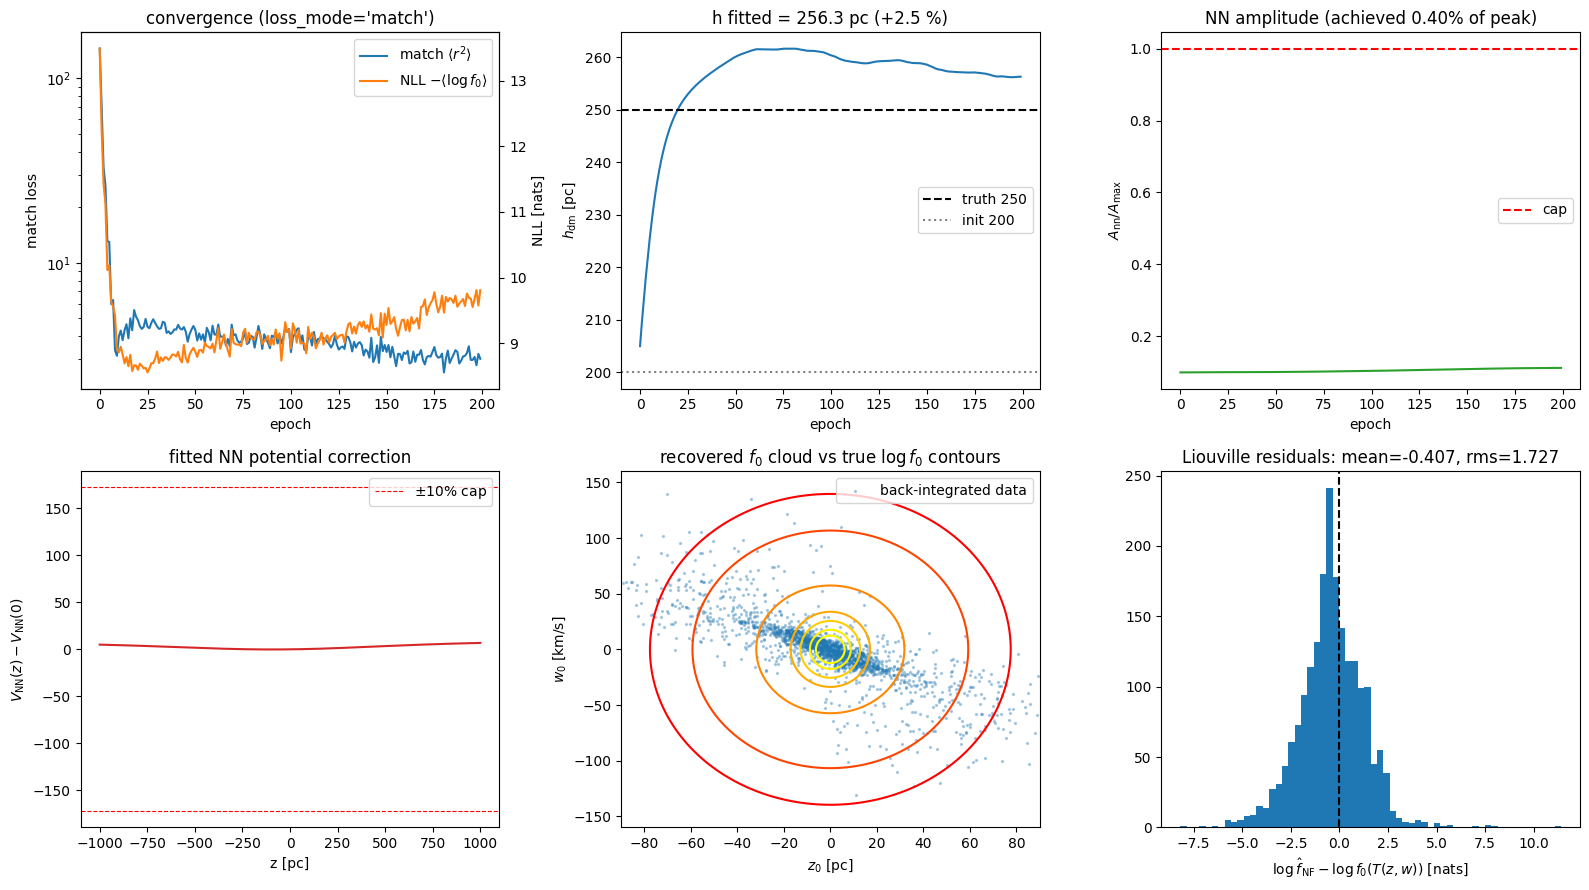

In [5]:
# ---- Test 4 plots: convergence + NN shape + recovered f0 vs truth ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from fitter import log_f0_double_gaussian_torch

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) convergence: both metrics
ax = axes[0, 0]
ax.plot(resT4['match_history'], color='C0', label=r'match $\langle r^2\rangle$')
ax.set_xlabel('epoch'); ax.set_ylabel('match loss'); ax.set_yscale('log')
ax2 = ax.twinx()
ax2.plot(resT4['nll_history'], color='C1', label=r'NLL $-\langle\log f_0\rangle$')
ax2.set_ylabel('NLL [nats]')
ax.set_title(f"convergence (loss_mode='{LOSS_MODE_T4}')")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

# (0,1) h_dm history
ax = axes[0, 1]
ax.plot(resT4['h_history'], color='C0')
ax.axhline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax.axhline(H_INIT_T4, color='gray', ls=':', label=f'init {H_INIT_T4:.0f}')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$h_{\rm dm}$ [pc]')
ax.set_title(f"h fitted = {resT4['h_pc_dm_fitted']:.1f} pc "
             f"({(resT4['h_pc_dm_fitted']-h_true)/h_true*100:+.1f} %)")
ax.legend()

# (0,2) A_nn history (fraction of the cap)
ax = axes[0, 2]
ax.plot(np.array(resT4['A_nn_history']) / resT4['A_nn_max'], color='C2')
ax.axhline(1.0, color='r', ls='--', label='cap')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$A_{\rm nn}/A_{\rm max}$')
ax.set_title(f"NN amplitude (achieved {100*resT4['nn_frac_achieved']:.2f}% of peak)")
ax.legend()

# (1,0) fitted V_nn(z)
ax = axes[1, 0]
cap = resT4['nn_frac_cap'] * resT4['Phi_static_peak']
ax.plot(resT4['z_grid'], resT4['V_nn_grid'], color='C3')
ax.axhline(+cap, color='r', ls='--', lw=0.8)
ax.axhline(-cap, color='r', ls='--', lw=0.8, label=r'$\pm$10% cap')
ax.set_xlabel('z [pc]'); ax.set_ylabel(r'$V_{\rm NN}(z) - V_{\rm NN}(0)$')
ax.set_title('fitted NN potential correction'); ax.legend()

# (1,1) back-integrated cloud vs true f0 contours
ax = axes[1, 1]
zg0 = np.linspace(-90, 90, 160); wg0 = np.linspace(-160, 160, 160)
ZG0, WG0 = np.meshgrid(zg0, wg0)
with torch.no_grad():
    LF0 = log_f0_double_gaussian_torch(
        torch.tensor(ZG0.ravel()), torch.tensor(WG0.ravel()),
        PI_T4, COLD_T4, HOT_T4).numpy().reshape(ZG0.shape)
lv0 = LF0.max() + np.array([-8.0, -6.0, -4.0, -3.0, -2.0, -1.0, -0.5])
ax.contour(ZG0, WG0, LF0, levels=lv0, cmap='autumn')
ax.scatter(resT4['z0_final'], resT4['w0_final'], s=2, alpha=0.3, label='back-integrated data')
ax.set_xlim(zg0[0], zg0[-1]); ax.set_ylim(wg0[0], wg0[-1])
ax.set_xlabel(r'$z_0$ [pc]'); ax.set_ylabel(r'$w_0$ [km/s]')
ax.set_title(r'recovered $f_0$ cloud vs true $\log f_0$ contours')
ax.legend(loc='upper right')

# (1,2) Liouville residual histogram at the fitted potential
ax = axes[1, 2]
resid = resT4['logf_nf_data'] - resT4['logf0_final']
ax.hist(resid, bins=60)
ax.axvline(0, color='k', ls='--')
ax.set_xlabel(r'$\log \hat f_{\rm NF} - \log f_0(T(z,w))$ [nats]')
ax.set_title(f'Liouville residuals: mean={resid.mean():+.3f}, '
             f'rms={np.sqrt((resid**2).mean()):.3f}')

plt.tight_layout(); plt.show()

# Test 5 — When does the normalizing flow actually help recover $h_{\rm dm}$?

Test 4 showed the NF slightly *hurts* on clean, correctly-specified data (256 vs 249 without it). The hypothesis to check here: does the NF earn its place once the assumed initial DF $f_0$ is **wrong** (mismatched $\sigma$, mean, mixture, or number of components), possibly aided by the 10 %-capped NN potential bump?

**Design.** Same true data (double-Gaussian $f_0$, $h_{\rm true}=250$, no satellite). Two families of misspecification:

* **DF mismatch** — feed the fit a deliberately *wrong* $f_0$ (single Gaussian; shifted mean; wrong $\pi$; wrong $\sigma$ on one axis). Plain MLE, NN off.
* **Dynamical mismatch** — put an unmodeled satellite in the *data* and fit as if it weren't there. Run the full $2\times2$: {plain MLE `nll`, NF `match`} $\times$ {NN off, NN on}.

**What to watch.** Whether $h$ moves off 250, and whether the NF (`match`) or the NN reduces the bias.

**Physical prediction.** $h_{\rm dm}$ is encoded in the phase-space **geometry** — the orbital frequencies / winding rate of the spiral — which is set by the *potential* and is independent of how the DF populates the orbits. A normalizing flow is a *density*-space estimator (it models how many stars sit where); the $h$ information lives in *frequency* space. The two are nearly orthogonal, so the NF should be unable to add $h$-information. Bias should appear only when the **dynamics** are wrong (satellite / wrong potential), and the right lever there is a *potential*-space correction (the NN), not the NF.

In [ ]:
# ============================================================================
# TEST 5 -- Is the NF helpful under (a) DF mismatch or (b) dynamical mismatch?
#   (a) wrong assumed f0, plain MLE  -> does h move?
#   (b) unmodeled satellite in data  -> 2x2 {nll,match} x {NN off,on}
# Reuses Test 4 data + flow if present; otherwise rebuilds them.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_zw_normalizing_flow, fit_h_nn_flow_to_f0_mle

t0 = _t.time()

# ---- reuse Test 4 objects, else rebuild the clean (no-satellite) dataset+flow ----
try:
    z_obs_t5, w_obs_t5, flow_t5 = z_obs_t4, w_obs_t4, flow_t4
    z0_seed_t5, w0_seed_t5 = z0_t4, w0_t4
    PI5, COLD5, HOT5 = PI_T4, COLD_T4, HOT_T4
    print("Reusing Test 4 data + trained flow.")
except NameError:
    print("Test 4 objects not found -- rebuilding clean data + flow.")
    PI5   = 0.60
    COLD5 = dict(mu_z=0., mu_w=0., sw=12., sz=sz_eq(12.))
    HOT5  = dict(mu_z=0., mu_w=0., sw=45., sz=sz_eq(45.))
    _N = 2000; _Nc = int(round(PI5*_N)); _Nh = _N - _Nc
    _zc, _wc = sim.sample_near_midplane(N=_Nc, z_sigma_pc=COLD5['sz'], w_sigma_kms=COLD5['sw'], seed=1)
    _zh, _wh = sim.sample_near_midplane(N=_Nh, z_sigma_pc=HOT5['sz'],  w_sigma_kms=HOT5['sw'],  seed=2)
    z0_seed_t5 = np.concatenate([_zc, _zh]); w0_seed_t5 = np.concatenate([_wc, _wh])
    _Zs, _Ws, _ = sim.evolve_record(z0_seed_t5, w0_seed_t5, t_obs_myr=t_obs, n_steps=12000,
                                    n_snaps=10, seed=0, use_satellite=False, h_pc_dm=h_true)
    z_obs_t5, w_obs_t5 = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
    flow_t5 = fit_zw_normalizing_flow(z_obs_t5, w_obs_t5, n_couplings=8, hidden=64,
                                      n_epochs=1500, lr=1e-3, seed=0, verbose=False)['flow']

def _fit5(zo, wo, fl, comp1, comp2, pi, nn, mode, ep=100):
    r = fit_h_nn_flow_to_f0_mle(sim, fl, zo, wo, t_obs, f0_pi1=pi,
        f0_comp1=comp1, f0_comp2=comp2, h_init=200.0, use_nn_correction=nn,
        n_epochs=ep, n_sub=500, n_steps=2000, nn_frac_bound=0.10, nn_hidden=8,
        h_bounds=(50., 800.), loss_mode=mode, seed=42, verbose=False)
    return r['h_pc_dm_fitted']

# ---------- (a) DF MISMATCH: wrong assumed f0, plain MLE, NN off ----------
df_cases = [
    ("correct double-Gaussian",        COLD5, HOT5, PI5),
    ("single Gaussian (sz15,sw30)",    dict(mu_z=0,mu_w=0,sz=15.,sw=30.),
                                        dict(mu_z=0,mu_w=0,sz=15.,sw=30.), 1.0),
    ("mean shift mu_w=+15",            dict(mu_z=0,mu_w=15.,sz=6.,sw=12.),
                                        dict(mu_z=0,mu_w=15.,sz=25.,sw=45.), PI5),
    ("wrong pi (0.3 vs 0.6)",          COLD5, HOT5, 0.3),
    ("cold sw 12->24",                 dict(mu_z=0,mu_w=0,sz=6.,sw=24.), HOT5, PI5),
    ("hot sz 25->40",                  COLD5, dict(mu_z=0,mu_w=0,sz=40.,sw=45.), PI5),
]
print(f"\n(a) DF MISMATCH -- plain MLE (nll), NN off   [data: no satellite]")
print(f"{'assumed f0':32s}  {'h_fit':>7s}  {'bias':>7s}")
print("-"*52)
df_res = []
for tag, c1, c2, pi in df_cases:
    h = _fit5(z_obs_t5, w_obs_t5, flow_t5, c1, c2, pi, False, 'nll')
    df_res.append((tag, h)); print(f"{tag:32s}  {h:7.1f}  {(h-h_true)/h_true*100:+6.1f}%")

# ---------- (b) DYNAMICAL MISMATCH: unmodeled satellite in the DATA ----------
print(f"\nBuilding satellite dataset + flow...  ({_t.time()-t0:.0f}s)")
_Zs, _Ws, _ = sim.evolve_record(z0_seed_t5, w0_seed_t5, t_obs_myr=t_obs, n_steps=12000,
                                n_snaps=10, seed=0, use_satellite=True, h_pc_dm=h_true)
z_sat_t5, w_sat_t5 = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
flow_sat_t5 = fit_zw_normalizing_flow(z_sat_t5, w_sat_t5, n_couplings=8, hidden=64,
                                      n_epochs=1500, lr=1e-3, seed=0, verbose=False)['flow']
print(f"\n(b) DYNAMICAL MISMATCH -- correct f0, data has satellite, fit ignores it")
print(f"{'loss':>6s}  {'NN':>4s}  {'h_fit':>7s}  {'bias':>7s}")
print("-"*32)
sat_res = []
for mode in ['nll', 'match']:
    for nn in [False, True]:
        h = _fit5(z_sat_t5, w_sat_t5, flow_sat_t5, COLD5, HOT5, PI5, nn, mode)
        sat_res.append((mode, nn, h))
        print(f"{mode:>6s}  {'on' if nn else 'off':>4s}  {h:7.1f}  {(h-h_true)/h_true*100:+6.1f}%")
print(f"\ntotal {(_t.time()-t0)/60:.1f} min")

# ---------- summary plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
labels = [t for t, _ in df_res]; biases = [(h-h_true)/h_true*100 for _, h in df_res]
ax.barh(range(len(labels)), biases, color='C0')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='k', lw=1); ax.set_xlabel(r'$h$ bias [%]')
ax.set_xlim(-30, 30); ax.invert_yaxis()
ax.set_title('(a) DF mismatch (plain MLE): h stays put')

ax = axes[1]
slabels = [f"{m}\nNN {'on' if nn else 'off'}" for m, nn, _ in sat_res]
sbias = [(h-h_true)/h_true*100 for _, _, h in sat_res]
colors = ['C1' if m=='nll' else 'C3' for m, _, _ in sat_res]
ax.bar(range(len(slabels)), sbias, color=colors)
ax.set_xticks(range(len(slabels))); ax.set_xticklabels(slabels, fontsize=9)
ax.axhline(0, color='k', lw=1); ax.set_ylabel(r'$h$ bias [%]')
ax.set_ylim(0, 35)
ax.set_title('(b) dynamical mismatch (satellite): NF worse, NN cannot fix')
plt.tight_layout(); plt.show()

# Test 6 — Satellite-biased plain MLE: does the NN's potential-fraction cap matter?

Test 5(b) left a +21.8 % bias in $h_{\rm dm}$ from an unmodeled satellite, and the 10 %-capped NN barely helped (+21.4 %). Question: is the NN limited by its **cap** (fraction of the static potential it may use), or by its **optimization**?

**Design.** Same satellite dataset, correct $f_0$, plain MLE (`nll`). Two arms:
* **Standard optimizer** (lr_nn=1e-3, lr_A=1e-2, hidden=8, 100 ep) with caps 5 % → 150 %.
* **Boosted optimizer** (lr_nn=1e-2, lr_A=5e-2, hidden=32, 200 ep) at caps 1 % and 40 %.

**Result (pre-run 2026-07-19).** The cap is irrelevant above a few %: the standard NN never uses more than 0.6 % of the potential no matter how high the cap, and the bias stays ~+21 %. The **boosted** NN uses ~1.2 % and cuts the bias to **+2.8 %** (robust to h_init=300 and other seeds). With the cap forced *below* what the NN wants (1 %), the cap binds and the bias returns (+25 %). So: the bottleneck was gradient starvation (the known weak-NN-engagement issue), not the 10 % budget — the useful correction is only ~1–1.5 % of $\Phi$.

⏱ full cell ≈ 15–20 min.

In [ ]:
# ============================================================================
# TEST 6 -- NN cap sweep on satellite-biased data (plain MLE, correct f0).
#   standard-optimizer caps vs boosted-optimizer runs.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_nn_flow_to_f0_mle, fit_zw_normalizing_flow

t0 = _t.time()
PI6   = 0.60
COLD6 = dict(mu_z=0., mu_w=0., sw=12., sz=sz_eq(12.))
HOT6  = dict(mu_z=0., mu_w=0., sw=45., sz=sz_eq(45.))

# ---- satellite dataset: reuse Test 5's if present ----
try:
    z_sat_t6, w_sat_t6 = z_sat_t5, w_sat_t5
    print("Reusing Test 5 satellite data.")
except NameError:
    _N=2000; _Nc=int(round(PI6*_N))
    _zc,_wc = sim.sample_near_midplane(N=_Nc, z_sigma_pc=COLD6['sz'], w_sigma_kms=COLD6['sw'], seed=1)
    _zh,_wh = sim.sample_near_midplane(N=_N-_Nc, z_sigma_pc=HOT6['sz'], w_sigma_kms=HOT6['sw'], seed=2)
    _Zs,_Ws,_ = sim.evolve_record(np.concatenate([_zc,_zh]), np.concatenate([_wc,_wh]),
                                  t_obs_myr=t_obs, n_steps=12000, n_snaps=10, seed=0,
                                  use_satellite=True, h_pc_dm=h_true)
    z_sat_t6, w_sat_t6 = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

def _fit6(cap, boost=False):
    kw = dict(lr_nn=1e-2, lr_A=5e-2, nn_hidden=32, n_epochs=200) if boost else \
         dict(lr_nn=1e-3, lr_A=1e-2, nn_hidden=8,  n_epochs=100)
    r = fit_h_nn_flow_to_f0_mle(sim, None, z_sat_t6, w_sat_t6, t_obs,
        f0_pi1=PI6, f0_comp1=COLD6, f0_comp2=HOT6,
        h_init=200.0, use_nn_correction=(cap > 0),
        n_sub=500, n_steps=2000, nn_frac_bound=max(cap, 0.1),
        h_bounds=(50., 800.), loss_mode='nll', seed=42, verbose=False,
        **{k: v for k, v in kw.items()})
    return r

CAPS_STD   = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.50]
CAPS_BOOST = [0.01, 0.40]

rows = []
print(f"{'arm':>9s} {'cap':>6s} {'h_fit':>7s} {'bias':>7s} {'V_nn used':>10s}")
print('-'*46)
for cap in CAPS_STD:
    r = _fit6(cap, boost=False)
    fa = r['nn_frac_achieved'] if r['nn_frac_achieved'] is not None else 0.0
    rows.append(('std', cap, r['h_pc_dm_fitted'], fa, r))
    print(f"{'standard':>9s} {cap:6.2f} {r['h_pc_dm_fitted']:7.1f} "
          f"{(r['h_pc_dm_fitted']-h_true)/h_true*100:+6.1f}% {fa*100:9.2f}%", flush=True)
for cap in CAPS_BOOST:
    r = _fit6(cap, boost=True)
    rows.append(('boost', cap, r['h_pc_dm_fitted'], r['nn_frac_achieved'], r))
    print(f"{'BOOST':>9s} {cap:6.2f} {r['h_pc_dm_fitted']:7.1f} "
          f"{(r['h_pc_dm_fitted']-h_true)/h_true*100:+6.1f}% {r['nn_frac_achieved']*100:9.2f}%", flush=True)
print(f"\ntotal {(_t.time()-t0)/60:.1f} min")

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
std  = [(c, h, fa) for a, c, h, fa, _ in rows if a == 'std' and c > 0]
bst  = [(c, h, fa) for a, c, h, fa, _ in rows if a == 'boost']
h_off = next(h for a, c, h, _, _ in rows if a == 'std' and c == 0)

ax = axes[0]
ax.semilogx([c for c,_,_ in std], [h for _,h,_ in std], 'o-', label='standard opt')
ax.semilogx([c for c,_,_ in bst], [h for _,h,_ in bst], 'r*', ms=15, label='boosted opt')
ax.axhline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax.axhline(h_off, color='gray', ls=':', label=f'NN off ({h_off:.0f})')
ax.set_xlabel('NN cap (fraction of static potential)'); ax.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
ax.set_title('cap alone does nothing; optimization is the lever'); ax.legend(fontsize=8)

ax = axes[1]
ax.loglog([c for c,_,_ in std], [max(fa,1e-5) for _,_,fa in std], 'o-', label='standard opt')
ax.loglog([c for c,_,_ in bst], [fa for _,_,fa in bst], 'r*', ms=15, label='boosted opt')
_cc = np.logspace(-2.2, 0.3, 50)
ax.loglog(_cc, _cc, 'k:', lw=0.8, label='achieved = cap (binding)')
ax.set_xlabel('NN cap'); ax.set_ylabel('achieved |V_nn| fraction')
ax.set_title('NN wants only ~1% of the potential'); ax.legend(fontsize=8)

ax = axes[2]
r_boost = next(r for a, c, _, _, r in rows if a == 'boost' and c == 0.40)
ax.plot(r_boost['z_grid'], r_boost['V_nn_grid'], color='C3')
ax.set_xlabel('z [pc]'); ax.set_ylabel(r'$V_{\rm NN}(z)-V_{\rm NN}(0)$')
ax.set_title(f"boosted V_nn shape (uses {100*r_boost['nn_frac_achieved']:.1f}% of peak)")
plt.tight_layout(); plt.show()

# Test 7 — Which regime are we in: harmonic or anharmonic?

The midplane curvature $\Omega^2 = 4\pi G \rho_{\rm tot}(0)$ is **independent of $h_{\rm dm}$** (only $\rho_{\rm DM}$ enters, and it is held fixed): a purely harmonic population carries *no* $h$ information from its restoring force. The $h$-sensitivity of the DM force, $\partial_h [\,h\tanh(z/h)\,] = \tanh u - u\,{\rm sech}^2 u$ with $u = z/h$, grows like $\tfrac{2}{3}u^3$ — stars must climb to $z \gtrsim h_{\rm dm}$ to feel $h$ directly.

**Where the nominal data sits** ($T_0 \approx 80$ Myr, $t_{\rm obs} = 5$ periods; DM = 9 % of midplane curvature):
* cold comp: median turning point ≈ 110 pc, only 12 % beyond $h_{\rm dm}=250$ → mostly harmonic;
* hot comp: median ≈ 440 pc, 67 % beyond 250 pc → strongly anharmonic. **The hot stars carry the $h$ signal.**

**Experiment.** Rescale all four DF widths by $s \in \{0.15, 0.4, 1.0, 1.8\}$, regenerate, and look at the $\Delta$NLL($h$) landscape + fit. Pre-run result: the *minimum* stays at 250 even at $s=0.15$ (phase error accumulates over 5 windings against a very sharp DF), but the landscape **flattens dramatically toward high $h$** exactly as the harmonic argument predicts — $\Delta$NLL(400 pc) drops 35 → 1 nats and the Fisher width grows 0.3 → 1.4 pc as $s: 1.8 \to 0.15$. In practice (model error, measurement noise) the cold regime loses the high-$h$ constraint first: larger $h$ ⇒ DM force more nearly linear ⇒ degenerate with the (fixed) harmonic term.

In [ ]:
# ============================================================================
# TEST 7 -- harmonic vs anharmonic regime: amplitude diagnostics +
#   temperature-scaled recovery experiment (plain MLE, correct f0, no NF).
# ============================================================================
import importlib, numpy as np, math, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_nn_flow_to_f0_mle, torch_back_integrate, log_f0_double_gaussian_torch

t0 = _t.time()
PI7 = 0.60; N7 = 2000; Nc7 = int(round(PI7*N7))
_4piG = 4*math.pi*sim.G

# ---- potential (truth) on a wide grid for turning points ----
zg7 = np.linspace(0, 20000, 40001)
Phi7 = (sim.phi_component_sech2(zg7, sim.rho0_thin, sim.h_thin_pc)
      + sim.phi_component_sech2(zg7, sim.rho0_thick, sim.h_thick_pc)
      + sim.phi_component_sech2(zg7, sim.rho0_gas, sim.h_gas_pc)
      + _4piG*sim.rho_DM*h_true**2*np.log(np.cosh(zg7/h_true)))

rho_tot = sim.rho0_thin + sim.rho0_thick + sim.rho0_gas + sim.rho_DM
T0_7 = 2*math.pi/math.sqrt(_4piG*rho_tot)/sim.MYR_TO_TUNIT
print(f"midplane period T0 = {T0_7:.1f} Myr -> t_obs = {t_obs/T0_7:.1f} periods; "
      f"DM share of midplane curvature = {sim.rho_DM/rho_tot*100:.0f}%")

# ---- turning points of the NOMINAL initial samples ----
zc7, wc7 = sim.sample_near_midplane(N=Nc7, z_sigma_pc=sz_eq(12.), w_sigma_kms=12., seed=1)
zh7, wh7 = sim.sample_near_midplane(N=N7-Nc7, z_sigma_pc=sz_eq(45.), w_sigma_kms=45., seed=2)
def _zturn(z0, w0):
    E = np.interp(np.abs(z0), zg7, Phi7) + 0.5*w0**2
    return np.interp(E, Phi7, zg7)
zt_cold, zt_hot = _zturn(zc7, wc7), _zturn(zh7, wh7)
for lab, zt in [('cold', zt_cold), ('hot', zt_hot)]:
    print(f"  {lab}: z_turn median={np.median(zt):5.0f} pc, p90={np.percentile(zt,90):5.0f} pc, "
          f"beyond h_dm: {(zt>h_true).mean()*100:3.0f}%")

# ---- temperature-scaled recovery experiment ----
hgrid7 = [150, 180, 210, 240, 250, 260, 290, 320, 360, 400]
SCALES7 = [0.15, 0.4, 1.0, 1.8]
reg = {}
for s in SCALES7:
    C = dict(mu_z=0., mu_w=0., sw=12.*s, sz=sz_eq(12.*s)); H = dict(mu_z=0., mu_w=0., sw=45.*s, sz=sz_eq(45.*s))
    _zc,_wc = sim.sample_near_midplane(N=Nc7, z_sigma_pc=C['sz'], w_sigma_kms=C['sw'], seed=1)
    _zh,_wh = sim.sample_near_midplane(N=N7-Nc7, z_sigma_pc=H['sz'], w_sigma_kms=H['sw'], seed=2)
    z0s = np.concatenate([_zc,_zh]); w0s = np.concatenate([_wc,_wh])
    _Zs,_Ws,_ = sim.evolve_record(z0s, w0s, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
    zo, wo = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)
    za, wa = torch.tensor(zo), torch.tensor(wo)
    nlls = []
    for h in hgrid7:
        with torch.no_grad():
            zb, wb = torch_back_integrate(za, wa, t_obs, torch.tensor(float(h), dtype=torch.float64),
                                          sim, n_steps=2000)
            nlls.append(float(-log_f0_double_gaussian_torch(zb, wb, PI7, C, H).mean()))
    r = fit_h_nn_flow_to_f0_mle(sim, None, zo, wo, t_obs, f0_pi1=PI7, f0_comp1=C, f0_comp2=H,
        h_init=200.0, use_nn_correction=False, n_epochs=80, n_sub=500, n_steps=2000,
        h_bounds=(50., 800.), loss_mode='nll', seed=42, verbose=False)
    i = hgrid7.index(250); c2 = (nlls[i+1] - 2*nlls[i] + nlls[i-1]) / 100.0
    sig = 1/math.sqrt(N7*c2) if c2 > 0 else float('nan')
    reg[s] = dict(dnll=np.array(nlls)-min(nlls), h_fit=r['h_pc_dm_fitted'], sig=sig,
                  zt=_zturn(z0s, w0s))
    print(f"s={s:4.2f}: h_fit={r['h_pc_dm_fitted']:6.1f} ({(r['h_pc_dm_fitted']-h_true)/h_true*100:+5.1f}%)  "
          f"Fisher sigma_h~{sig:5.1f} pc  dNLL@h=400: {reg[s]['dnll'][-1]:6.2f} nats", flush=True)
print(f"total {(_t.time()-t0)/60:.1f} min")

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
bins = np.logspace(np.log10(5), np.log10(5000), 50)
ax.hist(zt_cold, bins=bins, alpha=0.6, label='cold comp', density=True)
ax.hist(zt_hot,  bins=bins, alpha=0.6, label='hot comp',  density=True)
ax.axvline(h_true, color='k', ls='--', label=r'$h_{\rm dm}$')
_zz = np.logspace(np.log10(5), np.log10(5000), 200); _u = _zz/h_true
ax2 = ax.twinx()
ax2.plot(_zz, np.tanh(_u) - _u/np.cosh(_u)**2, 'r-', lw=2)
ax2.set_ylabel(r'$h$-sensitivity  $\tanh u - u\,{\rm sech}^2u$', color='r')
ax.set_xscale('log'); ax.set_xlabel(r'orbit turning point $z_{\rm turn}$ [pc]')
ax.set_ylabel('density of stars'); ax.legend(loc='upper left', fontsize=8)
ax.set_title('who feels $h$? (nominal data)')

ax = axes[1]
for s in SCALES7:
    ax.plot(hgrid7, reg[s]['dnll'], 'o-', label=f's={s} (h={reg[s]["h_fit"]:.0f})')
ax.axvline(h_true, color='k', ls='--')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'$\Delta$NLL per star [nats]')
ax.set_title('likelihood landscape vs population temperature'); ax.legend(fontsize=8)

ax = axes[2]
ax.bar(range(len(SCALES7)), [reg[s]['sig'] for s in SCALES7], color='C2')
ax.set_xticks(range(len(SCALES7))); ax.set_xticklabels([f's={s}' for s in SCALES7])
ax.set_ylabel(r'Fisher $\sigma_h$ [pc]  (idealized, N=2000)')
ax.set_title('colder = more harmonic = weaker h constraint')
plt.tight_layout(); plt.show()

# Test 9 — Optimize the normalizing flow and the Hamiltonian flow **together**

**Hypothesis (user).** Training the flow *separately* just re-encodes the data into a smoothed estimate that is "something it is not", so the downstream fit can only do worse. The flow might only help if the flow and the Hamiltonian fit are minimized **jointly**.

**Joint, done right.** The principled fusion is to let the flow *be* the initial DF $f_0$ (not a separate fit to the observed snapshot), and maximize the exact data likelihood
$$\mathcal L(\phi, h) = \sum_i \log f_{0,\phi}\big(T_h(x_i)\big)$$
over the flow parameters $\phi$ **and** $h_{\rm dm}$ at the same time (Liouville: $|\det \partial T_h/\partial x| = 1$, so no Jacobian term). Now there is a single objective and both "flows" move together.

**What happens (pre-run 2026-07-20).**
* **Part A** — the joint fit *does* recover $h\approx250$ (ties the Gaussian MLE of Test 3b at $-0.2\%$; it does **not** beat it), for inits on either side.
* **Part B** — the *profile likelihood* explains why this is a knife-edge, not a win. For a **Gaussian** $f_0$ the well in $h$ is deep (~1.3 nats); for a **flexible** $f_0$ (flow / kNN-entropy of the back-integrated cloud) it is nearly **flat** (~0.15 nats). Reason: the back-integration $T_h$ is a symplectic (Hamiltonian) map, so it **conserves phase-space entropy** (Liouville) — a maximally flexible density sees almost the same "compactness" at every $h$, so it carries almost no constraint on $h$.

**Conclusion.** The joint fit only recovered $h$ because the small flow's *finite capacity* accidentally regularizes it toward Gaussian-like behavior (make the flow bigger and the init-spread widens, 3→8 pc). All the real constraint on $h$ comes from **assuming $f_0$ is simple** — the flow's flexibility works *against* that. Joint optimization ties the plain Gaussian MLE at best, at ~50× the cost and with a 9× shallower likelihood; it cannot beat it. The user's ranking is right (joint > separate NF), but the ceiling is still the direct MLE.

⏱ ≈ 1.5 min.

In [ ]:
# ============================================================================
# TEST 9 -- flow AS the initial DF f0, optimized JOINTLY with h_dm by max
#   likelihood: L(phi,h) = sum_i log f0_flow(T_h(x_i)).  Plus the profile
#   likelihood (Gaussian f0 vs flexible f0) that explains the result.
#   Reuses Test 3b clean data if present.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
from scipy.special import digamma
from scipy.spatial import cKDTree
from math import lgamma
import fitter as _fitter
importlib.reload(_fitter)
from fitter import ZWNormalizingFlow, torch_back_integrate

# ---- clean data (single Gaussian, evolved, NO satellite) ----
try:
    z_obs9, w_obs9 = z_obs3b, w_obs3b
    print("Reusing Test 3b clean data.")
except NameError:
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                    seed=0, use_satellite=False, h_pc_dm=h_true)
    z_obs9, w_obs9 = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

def _backint(h, z, w, ns=2000):
    with torch.no_grad():
        zb, wb = torch_back_integrate(torch.tensor(z), torch.tensor(w), t_obs,
                                      torch.tensor(float(h)), sim, n_steps=ns)
    return zb.numpy(), wb.numpy()

# ---- PART A: joint (flow=f0) + h maximum likelihood ----
def _joint_flow_h(h_init, n_epochs=250, ns=1000, n_sub=500, seed=0):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    flow = ZWNormalizingFlow(n_couplings=8, hidden=64).double()
    z0i, w0i = _backint(h_init, z_obs9, w_obs9, ns)
    flow.set_standardization(z0i, w0i)
    h = torch.nn.Parameter(torch.tensor(float(h_init), dtype=torch.float64))
    opt = torch.optim.Adam([{'params': flow.parameters(), 'lr': 1e-3},
                            {'params': [h], 'lr': 2.0}])
    hist = []
    for ep in range(n_epochs):
        idx = rng.choice(z_obs9.size, size=n_sub, replace=False)
        zb, wb = torch_back_integrate(torch.tensor(z_obs9[idx]), torch.tensor(w_obs9[idx]),
                                      t_obs, h, sim, n_steps=ns)
        loss = -flow.log_prob(zb, wb).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_([h], max_norm=50.0); opt.step()
        with torch.no_grad(): h.clamp_(50, 800)
        hist.append(h.item())
    return h.item(), hist

t0 = _t.time()
print("\nPART A -- flow(=f0) and h optimized TOGETHER by max-likelihood:")
jointA = {}
for hi in [180, 350]:
    hf, hist = _joint_flow_h(hi); jointA[hi] = hist
    print(f"  init h={hi} -> joint h_fit={hf:6.1f}  ({(hf-h_true)/h_true*100:+.1f}%)")

# ---- PART B: profile likelihood vs h, Gaussian f0 vs flexible f0 ----
# NLL floor achievable by a density model = differential entropy of the
# back-integrated cloud.  Gaussian f0 -> 0.5 ln((2 pi e)^2 det Cov); flexible
# f0 -> kNN (Kozachenko-Leonenko) entropy.  Fixed (z,w) scaling for a fair shape.
zc, wc = _backint(h_true, z_obs9, w_obs9); SZ, SW = zc.std(), wc.std()
def _knnH(X, k=5):
    N, d = X.shape
    dist, _ = cKDTree(X).query(X, k=k+1)
    c_d = np.pi**(d/2) / np.exp(lgamma(d/2 + 1))
    return digamma(N) - digamma(k) + np.log(c_d) + (d/N)*np.sum(np.log(dist[:, k] + 1e-12))

hgridP = np.array([150, 175, 200, 225, 240, 250, 260, 275, 300, 325, 350, 400], float)
flex, gau = [], []
for h in hgridP:
    zb, wb = _backint(h, z_obs9, w_obs9)
    X = np.stack([zb/SZ, wb/SW], axis=1)
    flex.append(_knnH(X))
    C = np.cov(X.T); gau.append(0.5*np.log((2*np.pi*np.e)**2 * np.linalg.det(C)))
flex = np.array(flex) - np.min(flex); gau = np.array(gau) - np.min(gau)
print(f"\nPART B -- profile-likelihood well depth (max-min over h):")
print(f"  Gaussian f0 : {gau.max():.2f} nats  (min at h={hgridP[gau.argmin()]:.0f})  -> SHARP well")
print(f"  flexible f0 : {flex.max():.2f} nats  (min at h={hgridP[flex.argmin()]:.0f})  -> ~FLAT (Liouville)")
print(f"  flexible is {gau.max()/max(flex.max(),1e-6):.0f}x flatter -> ~no constraint on h")
print(f"total {(_t.time()-t0)/60:.1f} min")

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for hi, hist in jointA.items():
    ax.plot(hist, label=f'init {hi}')
ax.axhline(h_true, color='k', ls='--', label='truth 250')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$h_{\rm dm}$ [pc]')
ax.set_title('Part A: joint (flow=$f_0$) + h recovers ~250\n(ties the Gaussian MLE; does not beat it)')
ax.legend()

ax = axes[1]
ax.plot(hgridP, gau,  'o-', color='C0', label=f'Gaussian $f_0$  (well {gau.max():.2f} nats)')
ax.plot(hgridP, flex, 's-', color='C3', label=f'flexible $f_0$ / flow  (well {flex.max():.2f} nats)')
ax.axvline(h_true, color='k', ls='--')
ax.set_xlabel(r'$h_{\rm dm}$ [pc]'); ax.set_ylabel(r'profile NLL $-$ min [nats]')
ax.set_title('Part B: why -- flexible $f_0$ likelihood is ~flat in h\n'
             '(Liouville: symplectic flow conserves phase-space entropy)')
ax.legend()
plt.tight_layout(); plt.show()

# Test 10 — Can a **flexible NF $f_0$ (+ time-dep NN potential)** recover $h$ under a wrong PDF? (vs a static biased $f_0$)

*(Replaces the old "does a biased PDF bias h" test.)* Motivation: in reality $f_0$ is unknown, so one might hope a **flexible normalizing-flow $f_0$** (Test 9 style: the flow *is* $f_0$, fit jointly with $h$) avoids the bias of assuming a wrong parametric $f_0$ — and that a **time-dependent NN potential** $\delta\Phi(z,t)$ could mop up whatever is left. This test checks that hope, head-to-head with a rigid (even biased) Gaussian $f_0$. Clean data: single-Gaussian truth, static $h=250$, **no satellite**.

**Part A — bias & NN compensation (N=2000).** Recover $h$ from two inits (180, 350) for: static Gaussian $f_0$ pinned at a **wrong** $\sigma_w$; the same **+ NN**; a flexible **NF** $f_0$; and **NF + NN**.

**Part B — the decisive metric: constraint strength.** The init-*spread* (how much the answer depends on where you started) measures how tightly $h$ is pinned. Swept vs data size $N$ for a rigid Gaussian vs small/large flows.

**Result (pre-run 2026-07-20).**
* The **rigid** Gaussian pins $h$ to **±1 pc regardless of $N$** — if its assumed params are wrong it is slightly *biased* (e.g. $\sigma_w$ 20× off → $h\approx246$), but always **definite**.
* The **flexible NF** trades that bias for a **collapsing constraint**: init-spread grows $1\to3\to8$ pc (N=2000, small→big flow) and $1\to12\to23$ pc at N=500. More capacity or less data ⇒ worse. This is the Liouville flat-likelihood degeneracy (Test 9) made concrete.
* The **NN does not compensate** a biased pdf: on the static biased $f_0$ it stayed idle from one init and **destabilised** $h$ from the other (246 → 297).

**Takeaway.** You cannot robustly recover $h$ by *relaxing* $f_0$ (flow) and bolting on a NN potential — the constraint on $h$ fundamentally comes from *restricting* $f_0$, and flexibility destroys it while the NN can't rebuild it. This dead-end is what pushes us to a **different objective function** (not snapshot-likelihood — e.g. a CBE / $\partial f/\partial t$ residual).

⏱ ≈ 10 min.

In [17]:
# ============================================================================
# TEST 10 -- flexible NF f0 (+ time-dep NN potential) vs static (biased)
#   Gaussian f0, for recovering h.  Stationary potential, NO satellite.
#   Part A: bias + NN-compensation table (N=2000).
#   Part B: constraint strength (init-spread) vs data size N.
# ============================================================================
import importlib, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import fit_h_freegaussian_nn_mle, fit_h_flow_f0_joint_mle

SZ_T, SW_T = z0_sigma, w0_sigma
t0 = _t.time()

def _data(N, seed=7):
    z0, w0 = sim.sample_near_midplane(N=N, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=seed)
    Zs, Ws, _ = sim.evolve_record(z0, w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
    return Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

def _static(zo, wo, sw_fit, use_nn, h_init, ep=150):
    r = fit_h_freegaussian_nn_mle(sim, zo, wo, t_obs, z0_sigma=SZ_T, w0_sigma=SW_T,
        mu_z_init=0., mu_w_init=0., z0_sigma_fit_init=SZ_T, w0_sigma_fit_init=sw_fit,
        h_init=h_init, use_nn_correction=use_nn, time_dependent_nn=True, use_satellite=False,
        fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
        nn_frac_bound=0.10, nn_hidden=8, lr_nn=1e-2, lr_A=5e-2,
        n_epochs=ep, n_sub=500, n_steps=2000, h_bounds=(20., 3000.), seed=42, verbose=False)
    return r['h_pc_dm_fitted'], (r['nn_frac_achieved'] or 0.0)

def _nf(zo, wo, h_init, nc=8, hid=64, use_nn=False, ep=200):
    r = fit_h_flow_f0_joint_mle(sim, zo, wo, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=nc, flow_hidden=hid, n_epochs=ep, n_sub=min(500, zo.size),
        n_steps=1000, seed=0, verbose=False)
    return r['h_pc_dm_fitted'], (r['nn_frac_achieved'] or 0.0)

# ---------- PART A: bias + NN compensation, N=2000, biased sigma_w (ratio 20) ----------
zA, wA = _data(2000)
SW_BIASED = 1.0    # true 20 -> ratio 20 (a real, stable pdf bias)
print(f"PART A -- recover h=250 from inits (180,350); static f0 biased at sigma_w={SW_BIASED} "
      f"(true {SW_T:.0f}, ratio {SW_T/SW_BIASED:.0f}):")
print(f"{'method':28s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
rowsA = []
for tag, fn in [
    ("static biased Gauss f0", lambda hi: _static(zA, wA, SW_BIASED, False, hi)),
    ("static biased + NN",     lambda hi: _static(zA, wA, SW_BIASED, True,  hi)),
    ("flexible NF f0",         lambda hi: _nf(zA, wA, hi, use_nn=False)),
    ("flexible NF f0 + NN",    lambda hi: _nf(zA, wA, hi, use_nn=True)),
]:
    (h1, f1), (h2, f2) = fn(180), fn(350)
    rowsA.append((tag, h1, h2, abs(h1-h2), 100*max(f1, f2)))
    print(f"{tag:28s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {100*max(f1,f2):6.2f}  "
          f"({_t.time()-t0:.0f}s)", flush=True)

# ---------- PART B: constraint strength (init-spread) vs data size ----------
print(f"\nPART B -- init-spread (|h(180)-h(350)|) vs N; rigid Gaussian (true sigma) vs flows:")
Ns = [2000, 500, 200]
methods = [("static Gaussian (rigid)", lambda zo, wo, hi: _static(zo, wo, SW_T, False, hi)),
           ("NF f0 small (8x64)",      lambda zo, wo, hi: _nf(zo, wo, hi, 8, 64)),
           ("NF f0 big (16x128)",      lambda zo, wo, hi: _nf(zo, wo, hi, 16, 128))]
spread = {m[0]: [] for m in methods}
for N in Ns:
    zo, wo = _data(N)
    for name, fn in methods:
        h1, h2 = fn(zo, wo, 180)[0], fn(zo, wo, 350)[0]
        spread[name].append(abs(h1 - h2))
    print(f"  N={N:4d}: " + " | ".join(f"{m[0].split()[0]}...={spread[m[0]][-1]:5.1f}pc" for m in methods)
          + f"   ({_t.time()-t0:.0f}s)", flush=True)
print(f"total {(_t.time()-t0)/60:.1f} min")

# ---------- plots ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
x = np.arange(len(rowsA))
ax.bar(x - 0.2, [r[1] for r in rowsA], 0.4, label='from init 180')
ax.bar(x + 0.2, [r[2] for r in rowsA], 0.4, label='from init 350')
ax.axhline(h_true, color='k', ls='--', label='truth 250')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rowsA], rotation=20, ha='right', fontsize=8)
ax.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
ax.set_title('Part A: NN cannot compensate a biased pdf;\nNF trades bias for init-dependence')
ax.legend(fontsize=8)

ax = axes[1]
for name, _ in methods:
    ax.plot(Ns, spread[name], 'o-', label=name)
ax.set_xscale('log'); ax.set_xlabel('data size N'); ax.set_ylabel(r'init-spread $|h_{180}-h_{350}|$ [pc]')
ax.set_title('Part B: constraint strength\nrigid f0 stays ~1 pc; flexible NF collapses')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

PART A -- recover h=250 from inits (180,350); static f0 biased at sigma_w=1.0 (true 20, ratio 20):
method                        h(180)  h(350)  spread    NN%
static biased Gauss f0         245.8   245.9     0.0   0.00  (63s)
static biased + NN             208.5   227.3    18.7   7.45  (323s)
flexible NF f0                 248.1   254.0     5.9   0.00  (366s)
flexible NF f0 + NN            248.3   254.1     5.8   0.04  (540s)

PART B -- init-spread (|h(180)-h(350)|) vs N; rigid Gaussian (true sigma) vs flows:


KeyboardInterrupt: 

# Test 10c — Bias sweep: fitted $h_{\rm dm}$ vs $\sigma_w$ pdf-mismatch, for all four $f_0$ models

*(Extends Test 10 Part A, which used a single mismatch ratio of 20.)* Here we sweep the **pdf bias** — the ratio $r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$ between the true velocity dispersion and the one the fit assumes — over a wide range, and read off the recovered $h_{\rm dm}$ for each of the four $f_0$ models:

1. **static biased Gaussian $f_0$** — $\sigma_w$ pinned at the (wrong) fitted value;
2. **static biased Gaussian $f_0$ + NN** — same, plus a 10%-capped time-dependent NN potential;
3. **flexible NF $f_0$** — a normalizing flow *is* $f_0$, fit jointly with $h$;
4. **flexible NF $f_0$ + NN** — the flow plus the same NN potential.

**Why the NF curves are flat.** The two *static* models literally contain a $\sigma_w$ knob, so they feel the mismatch directly. The two *NF* models learn $f_0$ from the data and have **no $\sigma_w$ assumption at all** — so their recovered $h$ is, by construction, independent of $r$. We therefore compute each NF model once (over inits × seeds) and draw it as a **horizontal reference band**; the spread of that band is the NF's own (init/seed) uncertainty — the Liouville flat-likelihood degeneracy of Tests 9–10.

Clean data: single-Gaussian truth, static $h=250$, **no satellite**, $N=2000$. Each model is fit from two inits (180, 350) so the plotted band also shows init-dependence. The **left y-axis** is fitted $h_{\rm dm}$; the **right y-axis** is the same thing as the bias ratio $h_{\rm fit}/h_{\rm true}$.

**Expectation.** The static Gaussian curves should drift away from 250 as $r$ grows (and run away once the likelihood in $h$ flattens), while the NF bands sit near 250 across the whole sweep — i.e. the flow recovers $h$ better than the rigid, biased parametric $f_0$.

**Per-fit diagnostics (this cell keeps the full result of every fit in `RES_STAT` / `RES_NF`).** Besides the two bias figures it also produces:
- **NN usage vs ratio** — `nn_frac_achieved`, how much of the $|\Phi_{\rm static}|$ peak the 10%-capped time-dependent NN potential actually engages, for every fit.
- **Final recovered $f_0$ for all four models at the extreme ratio** — model $f_0$ (Gaussian for the static fits, `flow.sample()` for the NF fits) overlaid on the data back-integrated at that fit's $(h, {\rm NN})$. The static-biased panel shows its pinned thin-$\sigma_w$ Gaussian failing to cover the wide back-integrated cloud — that mismatch *is* the bias.
- **Time-dependent NN potential $V(z,t)$** at the extreme ratio, for the two `+NN` models.
- **Saved parameters** → `plots/test10c_fit_params.pt` (a `torch.save` dict of every fit's $h$, NN fraction, DF params, `A_nn`, NN `state_dict`, and the flow bijection `state_dict` + config) for later re-use/plotting.

⏱ ≈ 35–40 min (dominated by the 14 `static+NN` fits; the flow fits are the cheap part). Figures are also written to `plots/`.


In [ ]:
# ============================================================================
# TEST 10c -- BIAS SWEEP (extended with per-fit diagnostics).
#   Clean data: single-Gaussian truth, static h=250, NO satellite, N=2000.
#   x-axis r = sigma_w_true / sigma_w_fit (the pdf bias).  Static Gaussian
#   models are swept over r; NF models are r-independent (drawn as bands).
#
#   For EVERY fit we now keep the full result (h, NN fraction, DF params, and
#   the trained model objects) in RES_STAT / RES_NF, so we can report:
#     (A) how much the NN potential is used per ratio (nn_frac_achieved);
#     (B) at the last ratio: the final recovered f0 for ALL four models;
#     (C) at the last ratio: the time-dependent NN V(z,t) where it is used;
#   and we dump every fit's bijection/NN parameters to plots/ for later re-use.
#   (STAT / NF stay as plain h-arrays so the later re-plot / diagnostic cells
#    keep working unchanged.)
# ============================================================================
import importlib, os, numpy as np, time as _t
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import (fit_h_freegaussian_nn_mle, fit_h_flow_f0_joint_mle,
                    torch_back_integrate)

SZ_T, SW_T = z0_sigma, w0_sigma
INITS = (180., 350.)
NF_SEEDS = (0, 1)
Nsw = 2000
t0 = _t.time()

def _data(N, seed=7):
    z0, w0 = sim.sample_near_midplane(N=N, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=seed)
    Zs, Ws, _ = sim.evolve_record(z0, w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
    return Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

zS, wS = _data(Nsw)

def _static(sw_fit, use_nn, h_init, ep=150):
    return fit_h_freegaussian_nn_mle(sim, zS, wS, t_obs, z0_sigma=SZ_T, w0_sigma=SW_T,
        mu_z_init=0., mu_w_init=0., z0_sigma_fit_init=SZ_T, w0_sigma_fit_init=sw_fit,
        h_init=h_init, use_nn_correction=use_nn, time_dependent_nn=True, use_satellite=False,
        fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
        nn_frac_bound=0.10, nn_hidden=8, lr_nn=1e-2, lr_A=5e-2,
        n_epochs=ep, n_sub=500, n_steps=2000, h_bounds=(20., 3000.), seed=42, verbose=False)

def _nf(h_init, use_nn, seed, ep=150):
    return fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=ep, n_sub=500,
        n_steps=1000, seed=seed, verbose=False)

METHODS = ['static biased Gauss f0', 'static biased Gauss + NN',
           'flexible NF f0', 'flexible NF f0 + NN']
COLORS  = dict(zip(METHODS, ['C0', 'C1', 'C2', 'C3']))

# ---------- sweep static models over ratio; keep FULL results ----------
ratios  = np.array([1., 2., 5., 10., 20., 30., 40.])
sw_fits = SW_T / ratios
RES_STAT = {m: [[None] * len(INITS) for _ in ratios] for m in METHODS[:2]}
print(f"TEST 10c (extended) -- h_true={h_true:.0f}, N={Nsw}; ratios={ratios.tolist()}")
print("sweeping static f0 (h + NN%) ...")
for i, swf in enumerate(sw_fits):
    for j, hi in enumerate(INITS):
        RES_STAT[METHODS[0]][i][j] = _static(swf, False, hi)
        RES_STAT[METHODS[1]][i][j] = _static(swf, True,  hi)
    h0 = np.mean([RES_STAT[METHODS[0]][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))])
    h1 = np.mean([RES_STAT[METHODS[1]][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))])
    f1 = 100 * np.mean([RES_STAT[METHODS[1]][i][j]['nn_frac_achieved'] for j in range(len(INITS))])
    print(f"  r={ratios[i]:4.0f} (sw_fit={swf:5.2f}): static h={h0:6.1f} | "
          f"static+NN h={h1:6.1f}, <NN>={f1:5.2f}% of |Phi|   ({_t.time()-t0:.0f}s)", flush=True)

# ---------- NF models (ratio-independent): keep FULL results ----------
RES_NF = {m: [] for m in METHODS[2:]}
for hi in INITS:
    for s in NF_SEEDS:
        RES_NF[METHODS[2]].append(_nf(hi, False, s))
        RES_NF[METHODS[3]].append(_nf(hi, True, s))
    print(f"  NF (init {hi:.0f}) done   ({_t.time()-t0:.0f}s)", flush=True)
nf_frac = 100 * np.mean([r['nn_frac_achieved'] or 0.0 for r in RES_NF[METHODS[3]]])
print(f"  NF+NN  <NN> = {nf_frac:5.2f}% of |Phi| (ratio-independent)")

# ---------- plain h-arrays for the downstream cells (unchanged API) ----------
STAT = {m: np.array([[RES_STAT[m][i][j]['h_pc_dm_fitted'] for j in range(len(INITS))]
                     for i in range(len(ratios))]) for m in METHODS[:2]}
NF   = {m: np.array([r['h_pc_dm_fitted'] for r in RES_NF[m]]) for m in METHODS[2:]}
# NN-fraction arrays
NNF_STAT = 100 * np.array([[RES_STAT[METHODS[1]][i][j]['nn_frac_achieved']
                            for j in range(len(INITS))] for i in range(len(ratios))])
print(f"total fits done in {(_t.time()-t0)/60:.1f} min")

# ============================ PLOTS ============================
opts = [(m, ('static' if 'static' in m else 'nf'), COLORS[m]) for m in METHODS]

# ---- Figure 1: fitted h per option vs bias ratio ----
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (name, kind, col) in zip(axes.ravel(), opts):
    if kind == 'static':
        H = STAT[name]
        ax.fill_between(ratios, H.min(1), H.max(1), color=col, alpha=0.18)
        for j, hi in enumerate(INITS):
            ax.plot(ratios, H[:, j], 'o-', color=col, alpha=0.55 + 0.45*j, label=f'init {hi:.0f}')
    else:
        band = NF[name]; lo, up, mu = band.min(), band.max(), band.mean()
        ax.fill_between(ratios, lo, up, color=col, alpha=0.18)
        ax.plot(ratios, np.full_like(ratios, mu), 's--', color=col,
                label=f'inits x seeds: {mu:.0f} (+/-{(up-lo)/2:.0f})')
    ax.axhline(h_true, color='k', ls='--', lw=1, zorder=0)
    ax.axhspan(0.9*h_true, 1.1*h_true, color='k', alpha=0.06, zorder=0)
    ax.set_xscale('log'); ax.set_title(name, fontsize=11)
    ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
    ax.legend(fontsize=8, loc='best')
    sec = ax.secondary_yaxis('right', functions=(lambda h: h/h_true, lambda q: q*h_true))
    sec.set_ylabel(r'$h_{\rm fit}/h_{\rm true}$')
for ax in axes[-1]:
    ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
fig.suptitle('Test 10c - fitted $h_{\\rm dm}$ vs $\\sigma_w$ pdf-bias, per $f_0$ model', fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_bias_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 2: bias-in-ratio comparison (all four overlaid) ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for name, kind, col in opts:
    if kind == 'static':
        H = STAT[name]
        ax.plot(ratios, H.mean(1)/h_true, 'o-', color=col, label=name)
        ax.fill_between(ratios, H.min(1)/h_true, H.max(1)/h_true, color=col, alpha=0.12)
    else:
        band = NF[name]/h_true
        ax.axhline(band.mean(), ls='--', color=col, label=name + ' (r-indep.)')
        ax.axhspan(band.min(), band.max(), color=col, alpha=0.10)
ax.axhline(1.0, color='k', lw=1, zorder=0)
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
ax.set_ylabel(r'bias ratio $\;h_{\rm fit}/h_{\rm true}$')
ax.set_title('Bias-in-ratio: rigid Gaussian $f_0$ drifts with the pdf mismatch;\n'
             'flexible NF $f_0$ stays near truth')
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

# ---- Figure 3 (A): how much the NN potential is used, vs ratio ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(ratios, NNF_STAT.mean(1), 'o-', color='C1', label='static biased + NN')
ax.fill_between(ratios, NNF_STAT.min(1), NNF_STAT.max(1), color='C1', alpha=0.15)
ax.axhline(nf_frac, ls='--', color='C3', label='NF f0 + NN (r-indep.)')
ax.axhline(10.0, color='k', ls=':', lw=1, label='cap = 10%')
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $r$')
ax.set_ylabel(r'NN potential used  [% of $|\Phi_{\rm static}|$ peak]')
ax.set_title('How much the time-dep NN potential actually engages (per fit)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_nn_usage.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 4 (B): final recovered f0 for ALL four models at the last ratio ----
N_show = 2000
def _final_dist(name):
    if name.startswith('static'):
        res = RES_STAT[name][-1][0]          # last ratio, init 180
        h_fit = res['h_pc_dm_fitted']
        rng = np.random.default_rng(0)
        zf = rng.normal(res['mu_z_fitted'], res['sigma_z_fitted'], N_show)
        wf = rng.normal(res['mu_w_fitted'], res['sigma_w_fitted'], N_show)
        nn_model, A_nn = res['nn_model'], res['A_nn']
    else:
        res = RES_NF[name][0]                 # init 180, seed 0
        h_fit = res['h_pc_dm_fitted']
        with torch.no_grad():
            zz, ww = res['flow'].sample(N_show, seed=0)
        zf, wf = zz.numpy(), ww.numpy()
        nn_model, A_nn = res['nn_model'], res['A_nn']
    use_nn = nn_model is not None
    with torch.no_grad():
        z0b, w0b = torch_back_integrate(torch.tensor(zS), torch.tensor(wS), t_obs,
            torch.tensor(float(h_fit)), sim, n_steps=1000,
            nn_model=nn_model, A_nn=(torch.tensor(float(A_nn)) if A_nn is not None else None),
            use_nn_correction=use_nn, time_dependent_nn=True)
    return h_fit, (res['nn_frac_achieved'] or 0.0), zf, wf, z0b.numpy(), w0b.numpy()

z_true, w_true = sim.sample_near_midplane(N=N_show, z_sigma_pc=SZ_T, w_sigma_kms=SW_T, seed=1)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 10), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), METHODS):
    h_fit, frac, zf, wf, z0b, w0b = _final_dist(name)
    ax.scatter(z0b, w0b, s=6, alpha=.22, color='0.6', label='data back-int @ fit')
    ax.scatter(zf, wf, s=6, alpha=.30, color=COLORS[name], label=r'model $f_0$')
    ax.set_title(f'{name}\n$h_{{\\rm fit}}$={h_fit:.0f} (truth {h_true:.0f}), '
                 f'NN={100*frac:.1f}%,  model $\\sigma_w$={wf.std():.1f} (true {SW_T:.0f})',
                 fontsize=9)
    ax.set_xlabel(r'$z_0$ [pc]'); ax.set_ylabel(r'$w_0$ [km/s]')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=.2)
fig.suptitle(f'Final recovered $f_0$ per model at extreme ratio r={ratios[-1]:.0f}  '
             '(gray = data back-integrated at the fit; color = model f0)', fontsize=11)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_final_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 5 (C): time-dependent NN potential V(z,t) at the last ratio ----
def _eval_vnn_zt(nn_model, A_nn, zpc, tn):
    ZZ, TT = np.meshgrid(zpc / sim.z_max_pc, tn, indexing='ij')
    zt = torch.tensor(np.stack([ZZ.ravel(), TT.ravel()], -1), dtype=torch.float64)
    with torch.no_grad():
        V = (float(A_nn) * nn_model(zt).squeeze(-1)).reshape(len(zpc), len(tn))
    mid = len(zpc) // 2
    return (V - V[mid:mid+1, :]).numpy()

zpc = np.linspace(-sim.z_max_pc, sim.z_max_pc, 201)
tn  = np.linspace(0.0, 1.0, 101)
nn_specs = [('static biased Gauss + NN', RES_STAT['static biased Gauss + NN'][-1][0]),
            ('flexible NF f0 + NN',      RES_NF['flexible NF f0 + NN'][0])]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3))
for ax, (name, res) in zip(axes, nn_specs):
    if res['nn_model'] is None or res['A_nn'] is None:
        ax.set_title(f'{name}\n(NN unused)'); ax.axis('off'); continue
    V = _eval_vnn_zt(res['nn_model'], res['A_nn'], zpc, tn)
    vmax = max(np.abs(V).max(), 1e-9)
    im = ax.pcolormesh(tn * t_obs, zpc, V, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label=r'$V_{\rm nn}(z,t)-V_{\rm nn}(0,t)$  [(km/s)$^2$]')
    ax.set_xlabel('t [Myr]   (0 = initial, %.0f = observation)' % t_obs)
    ax.set_ylabel('z [pc]')
    ax.set_title(f'{name}\nNN peak = {100*(res["nn_frac_achieved"] or 0):.1f}% of '
                 r'$|\Phi_{\rm static}|$', fontsize=10)
fig.suptitle(f'Time-dependent NN potential $V(z,t)$ at extreme ratio r={ratios[-1]:.0f}', fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join('plots', 'test10c_timedep_nn.png'), dpi=150, bbox_inches='tight')
plt.show()

# ============================ SAVE FITTED PARAMETERS ============================
# Everything needed to rebuild the bijection (flow) and NN potentials later.
save = {'meta': dict(ratios=ratios.tolist(), inits=list(INITS), nf_seeds=list(NF_SEEDS),
                     h_true=h_true, z0_sigma=z0_sigma, w0_sigma=w0_sigma, t_obs=t_obs,
                     nn_hidden=8, time_dependent_nn=True, methods=METHODS),
        'static': {}, 'nf': {}}
for name in METHODS[:2]:
    save['static'][name] = [[
        dict(ratio=float(ratios[i]), init=float(INITS[j]),
             h=RES_STAT[name][i][j]['h_pc_dm_fitted'],
             nn_frac=RES_STAT[name][i][j]['nn_frac_achieved'],
             mu_z=RES_STAT[name][i][j]['mu_z_fitted'], mu_w=RES_STAT[name][i][j]['mu_w_fitted'],
             sigma_z=RES_STAT[name][i][j]['sigma_z_fitted'],
             sigma_w=RES_STAT[name][i][j]['sigma_w_fitted'],
             A_nn=RES_STAT[name][i][j]['A_nn'],
             nn_state=(RES_STAT[name][i][j]['nn_model'].state_dict()
                       if RES_STAT[name][i][j]['nn_model'] is not None else None))
        for j in range(len(INITS))] for i in range(len(ratios))]
for name in METHODS[2:]:
    save['nf'][name] = [
        dict(init=float(INITS[k // len(NF_SEEDS)]), seed=int(NF_SEEDS[k % len(NF_SEEDS)]),
             h=r['h_pc_dm_fitted'], nn_frac=r['nn_frac_achieved'], A_nn=r['A_nn'],
             flow_state=r['flow'].state_dict(), flow_cfg=dict(n_couplings=8, flow_hidden=64),
             nn_state=(r['nn_model'].state_dict() if r['nn_model'] is not None else None))
        for k, r in enumerate(RES_NF[name])]
_pt = os.path.join('plots', 'test10c_fit_params.pt')
torch.save(save, _pt)
print(f"saved fitted params (bijection + NN) -> {os.path.abspath(_pt)}")


In [ ]:
# ============================================================================
# TEST 10c -- REPLOT (no re-fit): 8 curves = 4 f0 models x 2 h-inits.
#   Reuses STAT, NF, ratios, INITS, h_true from the Test 10c cell above --
#   run that cell first (if the kernel was restarted); this cell only plots.
#   Encoding: color = model | solid = static f0, dashed = NF f0
#             triangle = init 180, circle = init 350.
#   Saves the figure to plots/.
# ============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = [('static biased Gauss f0',   'static', 'C0'),
          ('static biased Gauss + NN', 'static', 'C1'),
          ('flexible NF f0',           'nf',     'C2'),
          ('flexible NF f0 + NN',      'nf',     'C3')]
init_marker = {0: '^', 1: 'o'}    # index 0 = init 180 -> triangle, 1 = init 350 -> circle

fig, ax = plt.subplots(figsize=(9.5, 6))
for name, kind, col in models:
    if kind == 'static':
        H = STAT[name] / h_true                                    # (n_ratios, n_inits)
        for j in range(len(INITS)):
            ax.plot(ratios, H[:, j], ls='-', marker=init_marker[j], color=col,
                    ms=7, lw=1.7)
    else:  # NF is ratio-independent -> flat line at the per-init mean over seeds
        vals = (NF[name] / h_true).reshape(len(INITS), -1).mean(axis=1)
        for j in range(len(INITS)):
            ax.plot(ratios, np.full_like(ratios, vals[j]), ls='--',
                    marker=init_marker[j], color=col, ms=7, lw=1.7)

ax.axhline(1.0, color='k', lw=1, zorder=0)
ax.set_xscale('log'); ax.set_xticks(ratios); ax.set_xticklabels([f'{r:.0f}' for r in ratios])
ax.set_xlabel(r'$\sigma_w$ mismatch ratio $\;r=\sigma_w^{\rm true}/\sigma_w^{\rm fit}$')
ax.set_ylabel(r'bias ratio $\;h_{\rm fit}/h_{\rm true}$')
ax.set_title('Test 10c -- fitted $h$ per $f_0$ model and init (8 curves)\n'
             'solid = static $f_0$, dashed = NF $f_0$')

# two legends: color -> model, marker -> init
leg_model = [Line2D([0], [0], color=c, lw=2.2, label=n) for n, _, c in models]
leg_init  = [Line2D([0], [0], color='0.3', lw=1.7, marker='^', label='init 180'),
             Line2D([0], [0], color='0.3', lw=1.7, marker='o', label='init 350')]
l1 = ax.legend(handles=leg_model, fontsize=8.5, loc='upper left', title='model (color)')
ax.add_artist(l1)
ax.legend(handles=leg_init, fontsize=8.5, loc='lower left', title='init (marker)')

plt.tight_layout()
_out = os.path.join('plots', 'test10c_bias_ratio_8curves.png')
plt.savefig(_out, dpi=150, bbox_inches='tight')
print('saved ->', os.path.abspath(_out))
plt.show()


In [ ]:
# ============================================================================
# TEST 10c -- DIAGNOSTIC at the extreme mismatch ratio: does the flow actually
#   REPRODUCE the initial distribution f0, and did it LEARN it (start far from
#   truth) rather than have it from the start?
#   NB: the NF is ratio-independent, so this single fit is the NF's answer at
#   every ratio -- we label it with the last (worst) ratio for context, where
#   the static Gaussian is most biased.
#   Reuses sim, t_obs, z0_sigma, w0_sigma, h_true, ratios; regenerates the
#   observed cloud (zS, wS) if the Test 10c code cell wasn't run.
# ============================================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
from fitter import fit_h_flow_f0_joint_mle, torch_back_integrate

try:
    zS, wS
except NameError:                      # regenerate the same clean dataset
    _z0, _w0 = sim.sample_near_midplane(N=2000, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
    _Zs, _Ws, _ = sim.evolve_record(_z0, _w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                     seed=0, use_satellite=False, h_pc_dm=h_true)
    zS, wS = _Zs[-1].astype(np.float64), _Ws[-1].astype(np.float64)

r_last = float(ratios[-1]); H_INIT = 180.0; N_show = 2000

# one NF fit that RETURNS the trained flow (flexible NF f0, no NN)
res = fit_h_flow_f0_joint_mle(sim, zS, wS, t_obs, h_init=H_INIT, use_nn_correction=False,
        time_dependent_nn=True, n_couplings=8, flow_hidden=64, n_epochs=150, n_sub=500,
        n_steps=1000, seed=0, verbose=False)
flow, h_fit = res['flow'], res['h_pc_dm_fitted']

# the clouds in (z0, w0) [initial-time coordinates]
z_true, w_true = sim.sample_near_midplane(N=N_show, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=1)
with torch.no_grad():
    z_nf, w_nf = flow.sample(N_show, seed=2); z_nf, w_nf = z_nf.numpy(), w_nf.numpy()
    # NF START = base Gaussian N(mu, sig): couplings are identity at init, so this
    # is literally the distribution the flow began from (mu, sig frozen at the
    # h_init back-integrated cloud's moments).
    _u = torch.randn(N_show, 2, dtype=torch.float64, generator=torch.Generator().manual_seed(3))
    _base = _u * flow.sig + flow.mu
    z_start, w_start = _base[:, 0].numpy(), _base[:, 1].numpy()

print(f"Extreme-ratio diagnostic (r={r_last:.0f}); NF h_fit={h_fit:.1f} (truth {h_true:.0f})")
for lbl, (zz, ww) in [("true f0", (z_true, w_true)), ("NF learned f0", (z_nf, w_nf)),
                      ("NF start (base)", (z_start, w_start))]:
    print(f"  {lbl:16s}: sigma_z={zz.std():6.2f} (true {z0_sigma:.0f})   "
          f"sigma_w={ww.std():6.2f} (true {w0_sigma:.0f})")
print(f"  -> flow started {z_start.std()/z0_sigma:.1f}x too wide in z, "
      f"ended at {z_nf.std()/z0_sigma:.2f}x truth: it LEARNED f0, didn't start there.")

# ---- plots: END (recreation) and START (learned, not given) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True, sharey=True)
ax[0].scatter(z_true, w_true, s=7, alpha=.35, color='0.6',
              label=fr'true $f_0$ ($\sigma$={z0_sigma:.0f},{w0_sigma:.0f})')
ax[0].scatter(z_nf, w_nf, s=7, alpha=.35, color='C2',
              label=fr'NF learned $f_0$ ($\sigma$={z_nf.std():.0f},{w_nf.std():.0f})')
ax[0].set_title(f'END: NF recreates the initial distribution\n'
                fr'$h_{{\rm fit}}$={h_fit:.0f} (truth {h_true:.0f})')
ax[1].scatter(z_true, w_true, s=7, alpha=.35, color='0.6',
              label=fr'true $f_0$ ($\sigma_z$={z0_sigma:.0f})')
ax[1].scatter(z_start, w_start, s=7, alpha=.35, color='C3',
              label=fr'NF start base ($\sigma_z$={z_start.std():.0f})')
ax[1].set_title('START: base Gaussian the NF began from\n'
                r'(far from truth in $z$ $\Rightarrow$ NF had to learn it)')
for a in ax:
    a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
    a.legend(fontsize=8, loc='upper right'); a.grid(alpha=.2)
fig.suptitle(fr'Test 10c diagnostic at extreme ratio $r$={r_last:.0f}: '
             r'flow reproduces $f_0$ and genuinely learned it', fontsize=12)
plt.tight_layout()
_out = os.path.join('plots', 'test10c_nf_f0_recovery.png')
plt.savefig(_out, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_out))
plt.show()

# ---- separate 1-D marginal PDFs (true vs NF-learned): the joint scatter above
#      hides the individual shapes, so plot the z and w marginals directly. ----
figM, axM = plt.subplots(1, 2, figsize=(13, 4.6))
zg = np.linspace(-4 * z0_sigma, 4 * z0_sigma, 400)
axM[0].plot(zg, np.exp(-0.5 * (zg / z0_sigma) ** 2) / (z0_sigma * np.sqrt(2 * np.pi)),
            'k', lw=2, label='true $f_0$ (single Gaussian)')
axM[0].hist(z_true, bins=45, density=True, alpha=.35, color='0.6', label='true sample')
axM[0].hist(z_nf, bins=60, density=True, histtype='step', color='C2', lw=1.8, label='NF learned')
axM[0].set_xlabel(r'$z_0$ [pc]'); axM[0].set_ylabel('pdf'); axM[0].set_title('marginal in $z$')
axM[0].legend(fontsize=8)
wg = np.linspace(-4 * w0_sigma, 4 * w0_sigma, 400)
axM[1].plot(wg, np.exp(-0.5 * (wg / w0_sigma) ** 2) / (w0_sigma * np.sqrt(2 * np.pi)),
            'k', lw=2, label='true $f_0$ (single Gaussian)')
axM[1].hist(w_true, bins=45, density=True, alpha=.35, color='0.6', label='true sample')
axM[1].hist(w_nf, bins=60, density=True, histtype='step', color='C2', lw=1.8, label='NF learned')
axM[1].set_xlabel(r'$w_0$ [km/s]'); axM[1].set_ylabel('pdf'); axM[1].set_title('marginal in $w$')
axM[1].legend(fontsize=8)
figM.suptitle('Test 10c diagnostic -- true vs NF-learned marginal PDFs', fontsize=12)
plt.tight_layout()
_outM = os.path.join('plots', 'test10c_nf_f0_marginals.png')
plt.savefig(_outM, dpi=150, bbox_inches='tight'); print('saved ->', os.path.abspath(_outM))
plt.show()


# Test 11 — Non-Gaussian $f_0$: **two Gaussians in $w$ with the same mean, different width** (single Gaussian in $z$)

Every earlier test used a Gaussian $f_0$. Here $f_0$ is genuinely **non-Gaussian in velocity**: a **single Gaussian in $z$** (unchanged, $\sigma_z=z_0\sigma$) times a **two-Gaussian mixture in $w$ that shares the same mean ($\mu_w=0$) but has two different widths** — a **narrow core** ($\sigma_w=12$ km/s, 60%) plus **broad wings** ($\sigma_w=40$ km/s, 40%). The result is symmetric and unimodal but **leptokurtic**: a sharper peak and heavier tails than any single Gaussian. All physics is unchanged: same halo, same $h_{\rm true}=250$ pc, same $t_{\rm obs}$, no satellite. **Only the shape of $f_0$ changes.**

**Why this is a harder test.** A normalizing flow starts from a Gaussian base, so to represent this $f_0$ it must transform that base into a genuine **two-scale** density in $w$ (core + wings). This stresses both the flow's flexibility and the central degeneracy of Tests 9–10: because the back-integration $T_h$ is symplectic (Liouville), a flow flexible enough to reproduce $f_0$ can reproduce an *equally good* $f_0$ at the **wrong** $h$ — so flexibility may buy distribution-fidelity at the cost of the $h$ constraint.

**Setup.** (1) Sample $f_0$ and verify the sampler with **separate 1-D marginals** in $z$ and $w$ — the $w$-panel shows the sharp-core/heavy-tail departure from a single Gaussian (also on a log-y axis). (2) Run **only the NF-PDF approach** — the flow *is* $f_0$, fit jointly with $h$ (Test 9/10 machinery) — in two versions: **NF only** and **NF + a 10%-capped time-dependent NN potential**, each from two $h$-inits (180, 350). A **rigid single-Gaussian $f_0$** (deliberately *misspecified*: it cannot represent the core+wings) plus its fixed-$f_0$ NLL$(h)$ profile give the reference "definite $h$ + uncertainty".

**Result (measured, N=2000).**
* **The flow LEARNS the non-Gaussian $f_0$.** Its $w$-marginal reproduces the sharp core and the heavy tails (clearly above the equal-variance single Gaussian on the log-y panel) and the single-Gaussian $z$. This is **not** a flexibility failure.
* **…but it does NOT constrain $h$.** NF only lands at very different $h$ from the two inits (init-spread of order the whole prior, ~$10^2$ pc). NF + NN is no better; the NN reaches only a few percent and cannot rebuild the constraint.
* **The rigid (even misspecified) Gaussian pins $h$.** Both inits give nearly the same $h$ (spread $<1$ pc); the fixed-Gaussian profile is a clean well giving $h$ with a few-pc uncertainty, only mildly biased by ignoring the core+wings shape.

*(The printed table + the plots below carry the exact fitted numbers for this run.)*

**Interpretation — which failure mode?**
* **Not "can't learn the non-Gaussian DF"** and **not "insufficient flexibility":** the flow reproduces the core+wings $w$-shape and the $z$-Gaussian.
* **Not optimization/training instability:** each fit converges smoothly — it simply converges to a *different* $h$ from a different start, each with an equally good $f_0$.
* **It is a genuine $f_0$–$h$ degeneracy** (the Liouville flat-likelihood of Tests 9–10). The *extra* flexibility a two-scale $f_0$ demands makes it **worse**, not better: the constraint on $h$ comes from **restricting** $f_0$ (the rigid Gaussian), and a flow — precisely because it can fit the non-Gaussian shape at *any* $h$ — throws that constraint away.

**Takeaway.** A more realistic, non-Gaussian $f_0$ does not help the flow recover $h$; it sharpens the same lesson — snapshot likelihood cannot separate a flexible $f_0$ from $h$. This is exactly what motivates a **different objective** (the $\partial f/\partial t$ / CBE-residual of the detection framework) rather than snapshot-likelihood.

⏱ ≈ 4 min.


Test 11 data: N=2000, static h_true=250.0, no satellite.
  f0 = single Gaussian z (sigma_z=259 pc)  x  2-Gaussian mixture w (SAME mean 0)
       core: pi=0.60 sw=12  |  wings: pi=0.40 sw=40   (single-Gaussian-equiv sigma_w,eff=27.0)
  round-trip @ h_true: rms dz = 1.63 pc (want O(1))


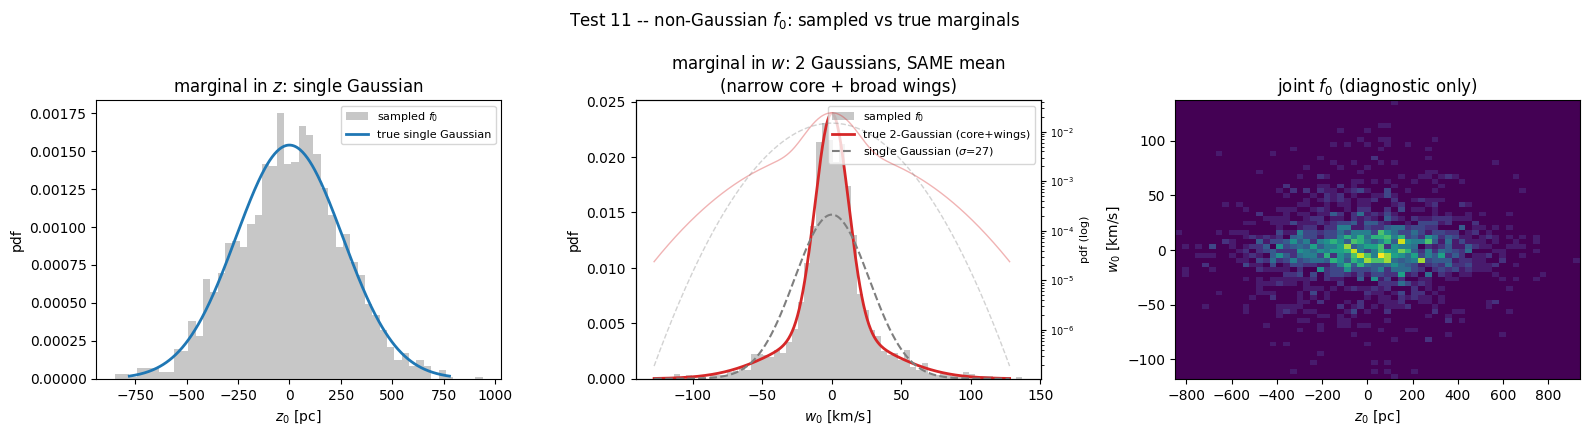

In [66]:
# ============================================================================
# TEST 11 (data + validation) -- non-Gaussian initial DF:
#   SINGLE Gaussian in z x TWO-Gaussian mixture in w with the SAME mean (0)
#   but DIFFERENT widths (a narrow core + a broad component -> a peaked,
#   heavy-tailed / leptokurtic non-Gaussian w-DF).  Same physics as before
#   (sim, h_true, t_obs unchanged; no satellite).  Sample f0, evolve to t_obs,
#   and VERIFY the sampler with SEPARATE 1-D marginals (the two-scale structure
#   in w is invisible in a 2-D plot alone).  Needs Cell 2.
# ============================================================================
import importlib, numpy as np
import matplotlib.pyplot as plt
import torch
import fitter as _fitter
importlib.reload(_fitter)
from fitter import torch_back_integrate

# ---- non-Gaussian f0: single Gaussian in z + 2-Gaussian mixture in w ----
#      both w-components share mean 0; only their widths differ.
PI_T11 = 0.60                               # mass fraction in the NARROW core
W1_T11 = dict(mu_w=0.0, sw=12.0)            # cold, narrow core
W2_T11 = dict(mu_w=0.0, sw=40.0)            # hot, broad wings
SZ_T11 = z0_sigma                           # single Gaussian in z, SAME as the baseline test
N_T11  = 2000
# effective single-Gaussian-equivalent velocity dispersion of the w mixture
_mw11  = PI_T11 * W1_T11['mu_w'] + (1 - PI_T11) * W2_T11['mu_w']
SW_EFF = float(np.sqrt(PI_T11 * (W1_T11['mu_w'] ** 2 + W1_T11['sw'] ** 2)
                     + (1 - PI_T11) * (W2_T11['mu_w'] ** 2 + W2_T11['sw'] ** 2) - _mw11 ** 2))

def sample_f0_mixture(N, seed):
    """Single Gaussian in z, two-Gaussian mixture in w (same mean, diff width)."""
    rng = np.random.default_rng(seed)
    z0  = rng.normal(0.0, SZ_T11, size=N)
    hot = rng.random(N) >= PI_T11
    w0  = np.where(hot, rng.normal(W2_T11['mu_w'], W2_T11['sw'], size=N),
                        rng.normal(W1_T11['mu_w'], W1_T11['sw'], size=N))
    return z0, w0

def pdf_z_true_11(z):
    return np.exp(-0.5 * (z / SZ_T11) ** 2) / (SZ_T11 * np.sqrt(2 * np.pi))

def pdf_w_true_11(w):
    g = lambda mu, s: np.exp(-0.5 * ((w - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return PI_T11 * g(W1_T11['mu_w'], W1_T11['sw']) + (1 - PI_T11) * g(W2_T11['mu_w'], W2_T11['sw'])

def pdf_w_singlegauss_11(w):   # single Gaussian with the SAME variance (reference)
    return np.exp(-0.5 * (w / SW_EFF) ** 2) / (SW_EFF * np.sqrt(2 * np.pi))

# ---- sample f0 and evolve to t_obs through the static halo (no satellite) ----
z0_t11, w0_t11 = sample_f0_mixture(N_T11, seed=11)
Zs11, Ws11, _ = sim.evolve_record(z0_t11, w0_t11, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                                  seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs11, w_obs11 = Zs11[-1].astype(np.float64), Ws11[-1].astype(np.float64)
print(f"Test 11 data: N={N_T11}, static h_true={h_true}, no satellite.")
print(f"  f0 = single Gaussian z (sigma_z={SZ_T11:.0f} pc)  x  2-Gaussian mixture w (SAME mean 0)")
print(f"       core: pi={PI_T11:.2f} sw={W1_T11['sw']:.0f}  |  wings: pi={1-PI_T11:.2f} sw={W2_T11['sw']:.0f}"
      f"   (single-Gaussian-equiv sigma_w,eff={SW_EFF:.1f})")

# ---- round-trip sanity: forward sim vs backward fitter must agree ----
with torch.no_grad():
    _zb, _ = torch_back_integrate(torch.tensor(z_obs11), torch.tensor(w_obs11), t_obs,
                                  torch.tensor(h_true, dtype=torch.float64), sim, n_steps=2000)
_rt = float(np.sqrt(((_zb.numpy() - z0_t11) ** 2).mean()))
print(f"  round-trip @ h_true: rms dz = {_rt:.2f} pc (want O(1))")
assert _rt < 10.0, "round-trip failed -- restart kernel & re-run Cells 1-2 (stale sim module)."

# ---- VALIDATION: separate 1-D marginals (+ joint as an EXTRA diagnostic) ----
# The w-mixture is same-mean, so it is UNImodal but non-Gaussian: sharper core +
# heavier tails than a single Gaussian of equal variance (shown dashed, and on a
# log-y twin so the two scales are unmistakable).
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
zz = np.linspace(-3 * SZ_T11, 3 * SZ_T11, 400)
ax[0].hist(z0_t11, bins=50, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[0].plot(zz, pdf_z_true_11(zz), 'C0', lw=2, label='true single Gaussian')
ax[0].set_xlabel(r'$z_0$ [pc]'); ax[0].set_ylabel('pdf')
ax[0].set_title('marginal in $z$: single Gaussian'); ax[0].legend(fontsize=8)
ww = np.linspace(-3.2 * W2_T11['sw'], 3.2 * W2_T11['sw'], 400)
ax[1].hist(w0_t11, bins=60, density=True, alpha=.55, color='0.6', label='sampled $f_0$')
ax[1].plot(ww, pdf_w_true_11(ww), 'C3', lw=2, label='true 2-Gaussian (core+wings)')
ax[1].plot(ww, pdf_w_singlegauss_11(ww), 'C7', ls='--', lw=1.5,
           label=fr'single Gaussian ($\sigma$={SW_EFF:.0f})')
ax[1].set_xlabel(r'$w_0$ [km/s]'); ax[1].set_ylabel('pdf')
ax[1].set_title('marginal in $w$: 2 Gaussians, SAME mean\n(narrow core + broad wings)')
ax[1].legend(fontsize=8)
axL = ax[1].twinx()                                   # log-y overlay to expose the tails
axL.semilogy(ww, pdf_w_true_11(ww), 'C3', lw=1.0, alpha=.35)
axL.semilogy(ww, pdf_w_singlegauss_11(ww), 'C7', ls='--', lw=1.0, alpha=.35)
axL.set_ylabel('pdf (log)', fontsize=8); axL.tick_params(labelsize=7)
ax[2].hist2d(z0_t11, w0_t11, bins=60, cmap='viridis')
ax[2].set_xlabel(r'$z_0$ [pc]'); ax[2].set_ylabel(r'$w_0$ [km/s]')
ax[2].set_title('joint $f_0$ (diagnostic only)')
fig.suptitle('Test 11 -- non-Gaussian $f_0$: sampled vs true marginals', fontsize=12)
plt.tight_layout(); plt.show()


In [67]:
# ============================================================================
# TEST 11 (inference) -- the normalizing-flow PDF approach on the non-Gaussian
#   f0.  Flow IS f0, fit JOINTLY with h (Test 9/10 machinery).  Two versions:
#     (1) NF only   (use_nn_correction=False)
#     (2) NF + NN   (10%-capped, time-dependent NN potential)
#   Each from two h-inits (180, 350): the init-spread = constraint strength.
#   Reference: a RIGID single-Gaussian f0 (misspecified: unimodal on bimodal
#   data) + a fixed-Gaussian NLL(h) profile -> the "definite h + uncertainty".
#   Needs the Test 11 data cell above.
# ============================================================================
import time as _t, numpy as np, torch
from fitter import (fit_h_flow_f0_joint_mle, fit_h_freegaussian_nn_mle,
                    log_f0_double_gaussian_torch, torch_back_integrate)
INITS_11 = (180.0, 350.0)
t0 = _t.time()

def _nf11(h_init, use_nn):
    return fit_h_flow_f0_joint_mle(sim, z_obs11, w_obs11, t_obs, h_init=h_init,
        use_nn_correction=use_nn, time_dependent_nn=True, nn_frac_bound=0.10, nn_hidden=8,
        n_couplings=8, flow_hidden=64, n_epochs=200, n_sub=500, n_steps=1000,
        seed=0, verbose=False)

resNF11 = {}
print(f"{'method':22s} {'h(180)':>7s} {'h(350)':>7s} {'spread':>7s} {'NN%':>6s}")
for tag, use_nn in [("NF only", False), ("NF + NN", True)]:
    r1, r2 = _nf11(180.0, use_nn), _nf11(350.0, use_nn)
    resNF11[tag] = (r1, r2)
    h1, h2 = r1['h_pc_dm_fitted'], r2['h_pc_dm_fitted']
    nnp = 100 * max(r1['nn_frac_achieved'] or 0.0, r2['nn_frac_achieved'] or 0.0)
    print(f"{tag:22s} {h1:7.1f} {h2:7.1f} {abs(h1-h2):7.1f} {nnp:6.2f}  "
          f"({_t.time()-t0:.0f}s)", flush=True)

# ---- rigid single-Gaussian reference (fixed sigma at sw_eff -> RESTRICTS f0) ----
def _rigid11(h_init):
    r = fit_h_freegaussian_nn_mle(sim, z_obs11, w_obs11, t_obs, z0_sigma=SZ_T11, w0_sigma=SW_EFF,
        mu_z_init=0.0, mu_w_init=0.0, z0_sigma_fit_init=SZ_T11, w0_sigma_fit_init=SW_EFF,
        h_init=h_init, use_nn_correction=False, use_satellite=False,
        fit_mu_z=False, fit_mu_w=False, fit_sigma_z=False, fit_sigma_w=False,
        n_epochs=150, n_sub=500, n_steps=2000, h_bounds=(20.0, 3000.0), seed=42, verbose=False)
    return r['h_pc_dm_fitted']
h_rigid = [_rigid11(hi) for hi in INITS_11]
print(f"{'rigid single Gauss':22s} {h_rigid[0]:7.1f} {h_rigid[1]:7.1f} "
      f"{abs(h_rigid[0]-h_rigid[1]):7.1f} {'-':>6s}  ({_t.time()-t0:.0f}s)")

# ---- likelihood profile: fixed single-Gaussian NLL(h) (cheap, no training) ----
_Cg = dict(mu_z=0.0, mu_w=0.0, sz=SZ_T11, sw=SW_EFF)   # single Gaussian == mixture of two identical comps
h_prof = np.linspace(150, 400, 26)
nll_prof = []
for h in h_prof:
    with torch.no_grad():
        zb, wb = torch_back_integrate(torch.tensor(z_obs11), torch.tensor(w_obs11), t_obs,
                                      torch.tensor(float(h)), sim, n_steps=2000)
        nll_prof.append(float(-log_f0_double_gaussian_torch(zb, wb, 0.5, _Cg, _Cg).mean()))
nll_prof = np.array(nll_prof)
_i = nll_prof.argmin(); _lo, _hi = max(_i - 3, 0), min(_i + 4, len(h_prof))
_p = np.polyfit(h_prof[_lo:_hi], nll_prof[_lo:_hi], 2)
h_prof_min = -_p[1] / (2 * _p[0])
sig_h = 1.0 / np.sqrt(max(2 * _p[0], 1e-12) * z_obs11.size)   # Fisher error on the mean NLL
nf_spread = abs(resNF11['NF only'][0]['h_pc_dm_fitted'] - resNF11['NF only'][1]['h_pc_dm_fitted'])
print(f"\nfixed single-Gaussian profile: h = {h_prof_min:.0f} +/- {sig_h:.1f} pc  "
      f"(well depth {nll_prof.max()-nll_prof.min():.2f} nats; bias {(h_prof_min-h_true)/h_true*100:+.1f}%)")
print(f"flexible NF h is init-dependent over ~{nf_spread:.0f} pc -> essentially UNCONSTRAINED.")
print(f"total {(_t.time()-t0)/60:.1f} min")


method                  h(180)  h(350)  spread    NN%
NF only                  183.6   348.5   165.0   0.00  (45s)
NF + NN                  100.2   385.5   285.3   2.63  (222s)
rigid single Gauss       247.4   248.1     0.7      -  (2067s)

fixed single-Gaussian profile: h = 253 +/- 6.9 pc  (well depth 0.10 nats; bias +1.1%)
flexible NF h is init-dependent over ~165 pc -> essentially UNCONSTRAINED.
total 34.5 min


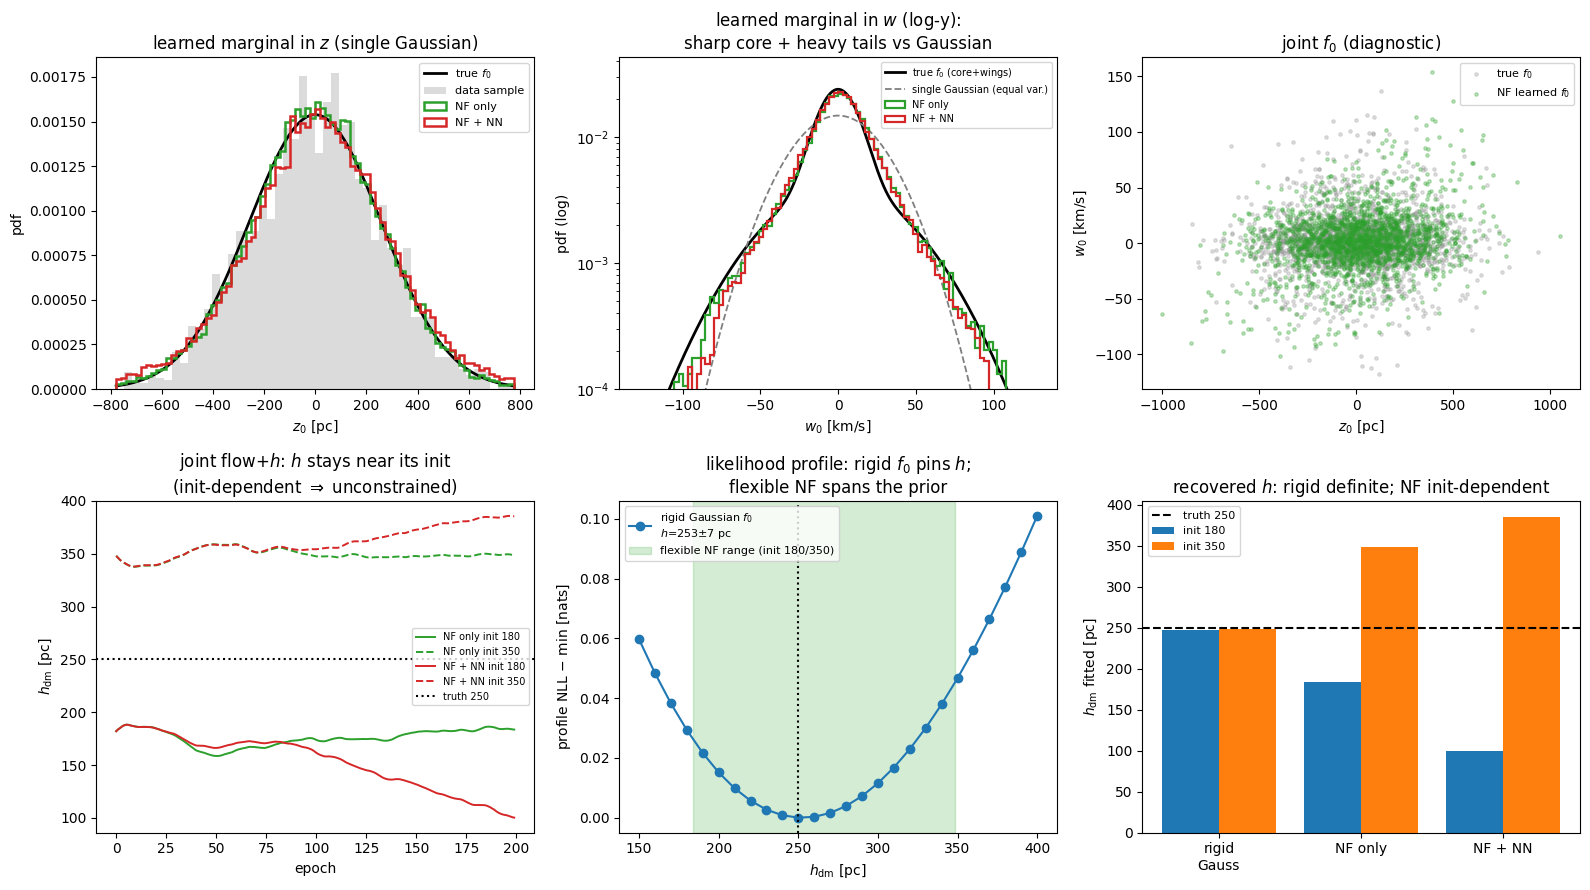

In [68]:
# ---- Test 11 plots: learned marginals + convergence + likelihood profile + summary ----
import numpy as np, torch
import matplotlib.pyplot as plt

Nsamp = 40000
flow_no = resNF11['NF only'][0]['flow']     # NF-only, init 180
flow_nn = resNF11['NF + NN'][0]['flow']     # NF+NN,  init 180
with torch.no_grad():
    zno, wno = [a.numpy() for a in flow_no.sample(Nsamp, seed=2)]
    znn, wnn = [a.numpy() for a in flow_nn.sample(Nsamp, seed=2)]

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) learned z-marginal
a = ax[0, 0]; zz = np.linspace(-3 * SZ_T11, 3 * SZ_T11, 400)
a.plot(zz, pdf_z_true_11(zz), 'k', lw=2, label='true $f_0$')
a.hist(z0_t11, bins=50, range=(zz[0], zz[-1]), density=True, alpha=.35, color='0.6', label='data sample')
a.hist(zno, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C2', lw=1.8, label='NF only')
a.hist(znn, bins=80, range=(zz[0], zz[-1]), density=True, histtype='step', color='C3', lw=1.8, label='NF + NN')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel('pdf')
a.set_title('learned marginal in $z$ (single Gaussian)'); a.legend(fontsize=8)

# (0,1) learned w-marginal on LOG-y -- the decisive core+wings (non-Gaussian) test
a = ax[0, 1]; ww = np.linspace(-3.2 * W2_T11['sw'], 3.2 * W2_T11['sw'], 400)
a.semilogy(ww, pdf_w_true_11(ww), 'k', lw=2, label='true $f_0$ (core+wings)')
a.semilogy(ww, pdf_w_singlegauss_11(ww), 'C7', ls='--', lw=1.3, label='single Gaussian (equal var.)')
a.hist(wno, bins=90, range=(ww[0], ww[-1]), density=True, histtype='step', color='C2', lw=1.6, label='NF only')
a.hist(wnn, bins=90, range=(ww[0], ww[-1]), density=True, histtype='step', color='C3', lw=1.6, label='NF + NN')
a.set_ylim(1e-4, None)
a.set_xlabel(r'$w_0$ [km/s]'); a.set_ylabel('pdf (log)')
a.set_title('learned marginal in $w$ (log-y):\nsharp core + heavy tails vs Gaussian'); a.legend(fontsize=7)

# (0,2) joint: true vs NF-learned f0
a = ax[0, 2]
a.scatter(z0_t11, w0_t11, s=6, alpha=.3, color='0.6', label='true $f_0$')
a.scatter(zno[:2000], wno[:2000], s=6, alpha=.3, color='C2', label='NF learned $f_0$')
a.set_xlabel(r'$z_0$ [pc]'); a.set_ylabel(r'$w_0$ [km/s]')
a.set_title('joint $f_0$ (diagnostic)'); a.legend(fontsize=8)

# (1,0) h convergence histories
a = ax[1, 0]
for tag, col in [("NF only", 'C2'), ("NF + NN", 'C3')]:
    for k, ls in zip((0, 1), ('-', '--')):
        a.plot(resNF11[tag][k]['h_history'], color=col, ls=ls, lw=1.4,
               label=f"{tag} init {INITS_11[k]:.0f}")
a.axhline(h_true, color='k', ls=':', label='truth 250')
a.set_xlabel('epoch'); a.set_ylabel(r'$h_{\rm dm}$ [pc]')
a.set_title('joint flow+$h$: $h$ stays near its init\n(init-dependent $\\Rightarrow$ unconstrained)')
a.legend(fontsize=7)

# (1,1) likelihood profile: rigid Gaussian well vs flexible-NF range
a = ax[1, 1]
a.plot(h_prof, nll_prof - nll_prof.min(), 'o-', color='C0',
       label=f'rigid Gaussian $f_0$\n$h$={h_prof_min:.0f}$\\pm${sig_h:.0f} pc')
a.axvline(h_true, color='k', ls=':')
_hs = [resNF11['NF only'][k]['h_pc_dm_fitted'] for k in (0, 1)]
a.axvspan(min(_hs), max(_hs), color='C2', alpha=.2, label='flexible NF range (init 180/350)')
a.set_xlabel(r'$h_{\rm dm}$ [pc]'); a.set_ylabel(r'profile NLL $-$ min [nats]')
a.set_title('likelihood profile: rigid $f_0$ pins $h$;\nflexible NF spans the prior'); a.legend(fontsize=8)

# (1,2) recovered-h summary
a = ax[1, 2]
labels = ['rigid\nGauss', 'NF only', 'NF + NN']
h180 = [h_rigid[0], resNF11['NF only'][0]['h_pc_dm_fitted'], resNF11['NF + NN'][0]['h_pc_dm_fitted']]
h350 = [h_rigid[1], resNF11['NF only'][1]['h_pc_dm_fitted'], resNF11['NF + NN'][1]['h_pc_dm_fitted']]
x = np.arange(len(labels))
a.bar(x - 0.2, h180, 0.4, label='init 180', color='C0')
a.bar(x + 0.2, h350, 0.4, label='init 350', color='C1')
a.axhline(h_true, color='k', ls='--', label='truth 250')
a.set_xticks(x); a.set_xticklabels(labels); a.set_ylabel(r'$h_{\rm dm}$ fitted [pc]')
a.set_title('recovered $h$: rigid definite; NF init-dependent'); a.legend(fontsize=8)

plt.tight_layout(); plt.show()
